In [ ]:
!pip install torch-optimizer

In [ ]:
# Import delle librerie necessarie
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch_optimizer as optim  # Ottimizzatori avanzati, come RAdam
from google.colab import drive
drive.mount('/content/drive')

# === 1. Caricamento dataset ===
df = pd.read_csv("/content/drive/MyDrive/df_finale_5_settimane_high.csv")
df["Time"] = pd.to_datetime(df["Timestamp"])  # Converte la colonna "Time" in formato datetime
df["hour"] = df["Time"].dt.hour  # Estrae l'ora da ogni timestamp
df["weekday"] = df["Time"].dt.weekday  # Estrae il giorno della settimana

# === 2. Configurazioni iniziali ===
window_size = 1380  # Dimensione della finestra temporale (input per il modello)
output_steps = 60  # Numero di step da predire in avanti
base_output_path = "/content/drive/MyDrive/modelli_high" # Directory per salvare output
os.makedirs(base_output_path, exist_ok=True)  # Crea la cartella se non esiste




Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# === Funzione sequenze ===
def create_sequences_single_step(valori, ore, giorni, window_size):
    X, y = [], []
    for i in range(len(valori) - window_size - 1):
        v = valori[i:i+window_size]
        h = ore[i:i+window_size]
        d = giorni[i:i+window_size]
        X.append(np.stack([v, h, d], axis=-1))
        y.append(valori[i+window_size])
    return np.array(X), np.array(y)

import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(channels)

    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual
        return F.relu(out)

class ConvLSTMNetImproved(nn.Module):
    def __init__(self, window_size):
        super().__init__()
        # Primo blocco conv + residual
        self.conv1 = nn.Conv1d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.resblock1 = ResidualBlock(64)
        self.pool1 = nn.MaxPool1d(2)
        self.drop1 = nn.Dropout(0.3)

        # Secondo blocco conv + residual
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)
        self.resblock2 = ResidualBlock(128)
        self.pool2 = nn.MaxPool1d(2)
        self.drop2 = nn.Dropout(0.3)

        # LSTM bidirezionale a due layer
        self.lstm1 = nn.LSTM(128, 128, batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(256, 128, batch_first=True)

        # Calcolo della dimensione finale dopo pool (assumendo due pool da 2)
        final_len = 128 * (((((window_size) // 2) // 2)))

        # Fully connected
        self.fc1 = nn.Linear(final_len, 100)
        self.fc2 = nn.Linear(100, 1)

    def forward(self, x):
        # x shape: (batch, time, features=3)
        x = x.permute(0, 2, 1)  # (batch, features, time)

        x = F.relu(self.bn1(self.conv1(x)))
        x = self.resblock1(x)
        x = self.pool1(x)
        x = self.drop1(x)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.resblock2(x)
        x = self.pool2(x)
        x = self.drop2(x)

        x = x.permute(0, 2, 1)  # (batch, time, features)
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)

        x = x.flatten(start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
# Colonne da escludere esplicitamente
excluded_columns = [
    "Timestamp", "hour", "weekday","Time",
    "ts-admin-basic-info-service-d8d4b4ff9-s7zth",
    "ts-admin-order-service-787856598f-fl56n",
    "ts-admin-route-service-5d486755c-mxt4j",
    "ts-admin-travel-service-7d4d447494-lz7vv",
    "ts-auth-service-5cd94cf4c9-pr4sc",
    "ts-basic-service-c57455994-5rf52",
    "ts-cancel-service-55b6778574-7zfnb",
    "ts-config-service-55f74d8b79-mt2ln",
    "ts-consign-service-69fdbff744-t4nnm",
    "ts-delivery-service-857d89f589-nrpbf",
    "ts-execute-service-667756b4bf-vrl4r",
    "ts-food-delivery-service-85c449576c-7jtrf",
    "ts-inside-payment-service-7f87878d9f-mqp8l",
    "ts-notification-service-66777dd945-g9l6f",
    "ts-payment-service-7fc4c49d89-7zrgj",
    "ts-preserve-other-service-5b9bbf9cf-hjzpg",
    "ts-price-service-55c8646c4c-hjw4b",
    "ts-rebook-service-79586f4dbc-lh6w9",
    "ts-route-plan-service-6594877d59-qrh8f",
    "ts-seat-service-54f7bb8465-rzgwd",
    "ts-station-service-798774f5d-dpsf5",
    "ts-train-service-c7fc88877-mm8n9",
    "ts-travel-plan-service-57865655f6-vklhv",
    "ts-travel2-service-5db558f8d9-4tk7g",
    "ts-verification-code-service-58d4c7b777-p96jk",
    "ts-wait-order-service-6f7f78bb5d-8f78g"
]

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

samples_per_day = 1440
train_days = 28
test_days = 7
train_len = train_days * samples_per_day
test_len = test_days * samples_per_day



columns_to_predict = [col for col in df.columns if col not in excluded_columns]

metriche_modelli = []

for col in columns_to_predict:
    print(f"\n➡️ Lavorando sulla colonna: {col}")
    output_dir = os.path.join(base_output_path, col)
    os.makedirs(output_dir, exist_ok=True)

    # Scaling
    scaler_val = MinMaxScaler()
    valori_scaled = scaler_val.fit_transform(df[col].values.reshape(-1, 1)).flatten()
    scaler_hour = MinMaxScaler()
    hours_scaled = scaler_hour.fit_transform(df["hour"].values.reshape(-1, 1)).flatten()
    scaler_week = MinMaxScaler()
    weekdays_scaled = scaler_week.fit_transform(df["weekday"].values.reshape(-1, 1)).flatten()

    # Training set
    X_train, y_train = create_sequences_single_step(
        valori_scaled[:train_len], hours_scaled[:train_len], weekdays_scaled[:train_len], window_size
    )

    # Test set start e end (evitando segmenti troppo piccoli)
    offset = np.random.randint(1, samples_per_day)
    test_start = train_len - window_size - output_steps + offset
    test_end = test_start + test_len

    segment_len = test_end - test_start
    if segment_len <= window_size + 1:
        test_start = train_len
        test_end = test_start + test_len
        segment_len = test_end - test_start
        if segment_len <= window_size + 1:
            print(f"❌ Impossibile creare sequenze per {col}, salto.")
            continue

    # Validation set
    X_val, y_val = create_sequences_single_step(
        valori_scaled[test_start:test_end],
        hours_scaled[test_start:test_end],
        weekdays_scaled[test_start:test_end],
        window_size
    )

    if len(X_val) == 0 or len(y_val) == 0:
        print(f"⚠️ Set di validazione vuoto per la colonna {col}, salto.")
        continue

    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
    X_val = torch.tensor(X_val, dtype=torch.float32)
    y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(-1)

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32)

    # Modello, criterio, ottimizzatore
    model = ConvLSTMNetImproved(window_size=window_size).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.RAdam(model.parameters(), lr=0.001)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_model_state = None
    patience = 5
    counter = 0
    num_epochs = 30

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                loss = criterion(preds, yb)
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {avg_train_loss:.6f} - Val Loss: {avg_val_loss:.6f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict()
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"⏹️ Early stopping attivato alla epoca {epoch+1}")
                break

    if best_model_state:
        model.load_state_dict(best_model_state)

    # Salvataggio curva loss
    plt.figure(figsize=(10, 4))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title(f"Loss Curve - {col}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(output_dir, f"loss_{col}.png"))
    plt.close()

    # === Previsione multi-step autoregressiva ===

    start_pred = test_start  # Inizio test set

    # Inizializza input con ultimi window_size valori reali *prima* del test
    pred_input_v = list(valori_scaled[start_pred - window_size:start_pred])
    pred_input_h = list(hours_scaled[start_pred - window_size:start_pred])
    pred_input_d = list(weekdays_scaled[start_pred - window_size:start_pred])

    predicted_scaled = []

    for step in range(output_steps):
        input_seq = np.stack([pred_input_v[-window_size:], pred_input_h[-window_size:], pred_input_d[-window_size:]], axis=-1)
        input_seq = input_seq.reshape(1, window_size, 3)
        input_tensor = torch.tensor(input_seq, dtype=torch.float32).to(device)

        with torch.no_grad():
            pred = model(input_tensor).cpu().numpy().flatten()[0]

        predicted_scaled.append(pred)

        # Aggiorna sequenze per prossimo step (autoregressione)
        pred_input_v.append(pred)

        # Aggiorna ore e giorni per prossimo step (se oltre dati usa ultimo valore)
        next_idx = start_pred + step
        if next_idx < len(hours_scaled):
            pred_input_h.append(hours_scaled[next_idx])
            pred_input_d.append(weekdays_scaled[next_idx])
        else:
            pred_input_h.append(pred_input_h[-1])
            pred_input_d.append(pred_input_d[-1])

    predicted_real = scaler_val.inverse_transform(np.array(predicted_scaled).reshape(-1, 1)).flatten()
    real_values = df[col].iloc[start_pred:start_pred + output_steps].values
    last_times = df["Time"].iloc[start_pred:start_pred + output_steps]

    # Plot previsioni vs reali
    plt.figure(figsize=(12, 5))
    plt.plot(last_times, real_values, label="Valori reali", linewidth=2)
    plt.plot(last_times, predicted_real, label="Previsioni", linestyle="--", color="darkred")
    plt.xlabel("Tempo")
    plt.ylabel("Valore")
    plt.title(f"Previsione ultimi {output_steps} step - {col}")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"forecast_{col}.png"))
    plt.close()

    # Metriche
    mse = mean_squared_error(real_values, predicted_real)
    mae = mean_absolute_error(real_values, predicted_real)
    r2 = r2_score(real_values, predicted_real)

    print(f"📊 Test MSE: {mse:.4f} - MAE: {mae:.4f} - R^2: {r2:.4f}")

    metriche_modelli.append({
        "colonna": col,
        "mse": mse,
        "mae": mae,
        "r2": r2
    })

    torch.save(model.state_dict(), os.path.join(output_dir, f"model_{col}.pt"))
    print(f"✅ Completato: modello e grafici salvati per: {col}")

# Salvataggio CSV metriche finali
df_metriche = pd.DataFrame(metriche_modelli)
df_metriche.to_csv(os.path.join(base_output_path, "valutazione_modelli.csv"), index=False)
print("📁 File delle metriche salvato:", os.path.join(base_output_path, "valutazione_modelli.csv"))

In [ ]:
import random

# Parametri
seq_len = 1440  # lunghezza sequenza
n_sequences = 30
days_limit = 10

# Filtra ultimi 7 giorni
ultimo_timestamp = df["Time"].max()
primo_timestamp = ultimo_timestamp - pd.Timedelta(days=days_limit)
df_last_week = df[df["Time"] >= primo_timestamp].reset_index(drop=True)

# Controlla dati sufficienti
max_start_idx = len(df_last_week) - seq_len
if max_start_idx <= 0:
    raise ValueError("Non ci sono abbastanza dati per estrarre anche una sequenza di 1440 campioni.")

# Estrai 5 start index casuali distinti
start_indices = set()
while len(start_indices) < n_sequences:
    idx = random.randint(0, max_start_idx)
    start_indices.add(idx)
start_indices = sorted(list(start_indices))

# Estrai le sequenze
sequenze = []
for start_idx in start_indices:
    end_idx = start_idx + seq_len
    sequenza = df_last_week.iloc[start_idx:end_idx].copy()
    sequenze.append(sequenza)

# Stampa info
for i, seq in enumerate(sequenze):
    print(f"Sequenza {i+1}: da {seq['Time'].min()} a {seq['Time'].max()} (righe: {len(seq)})")

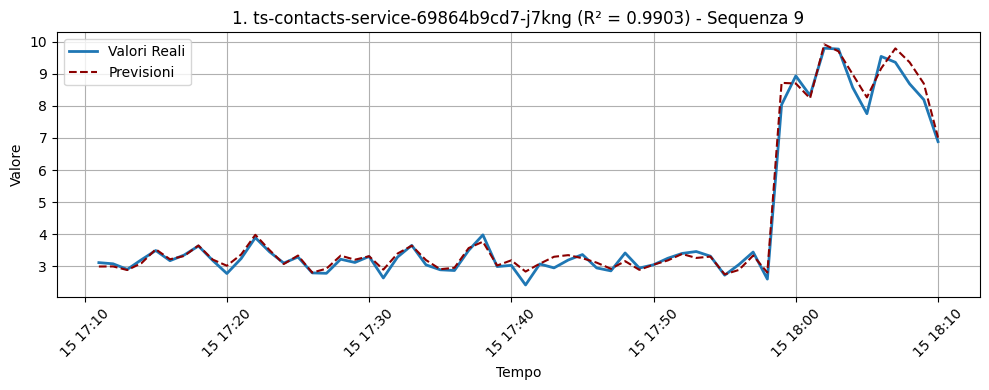

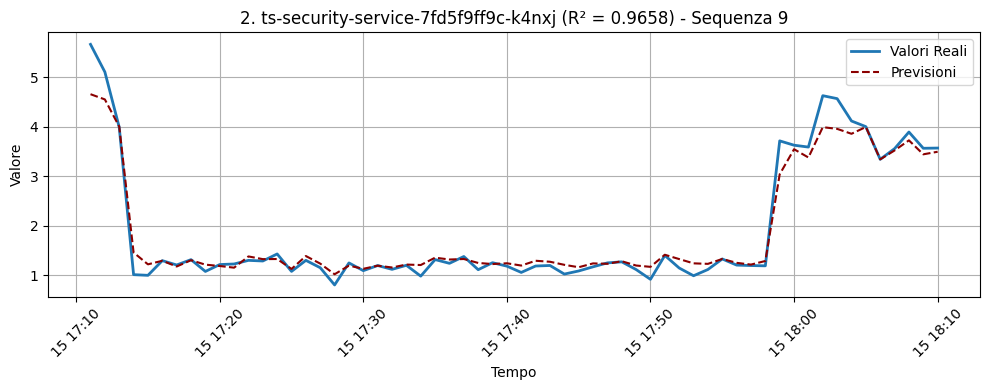

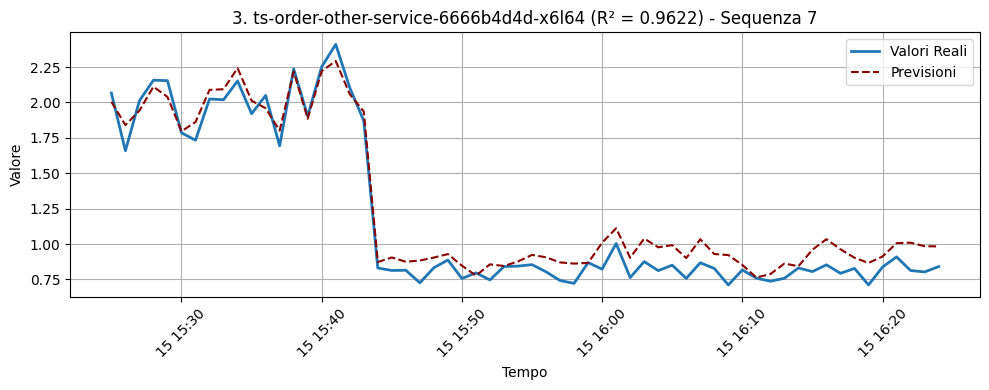

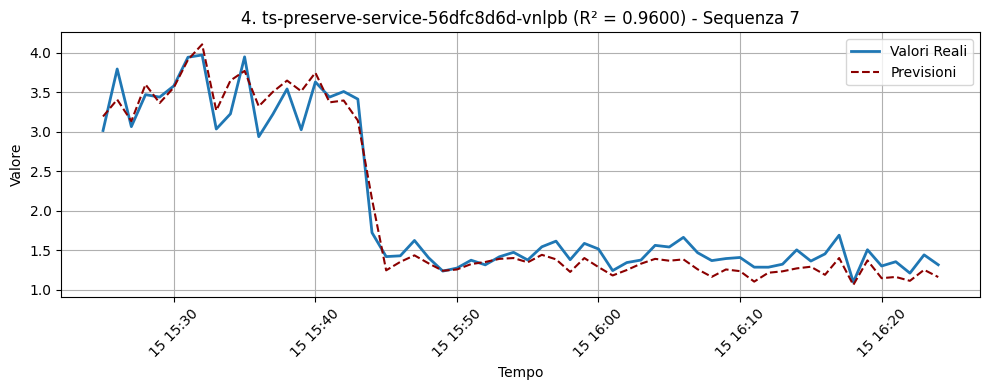

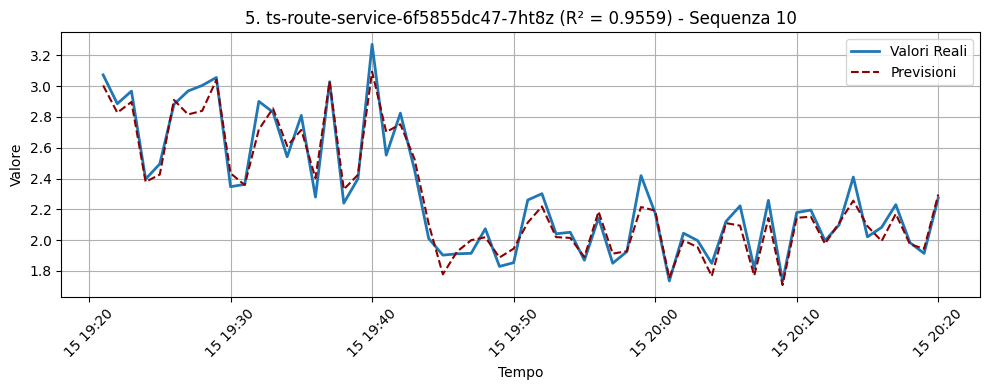

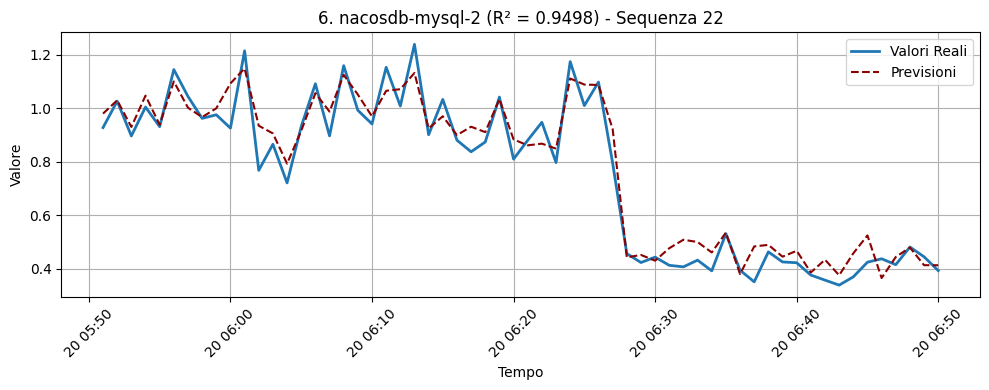

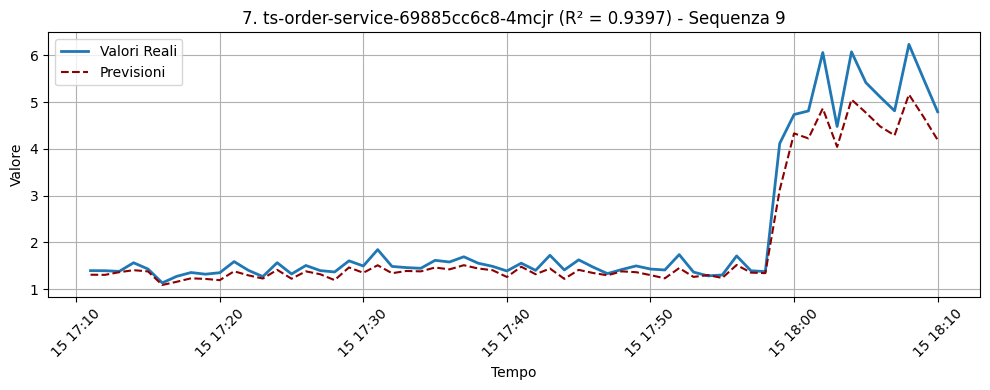

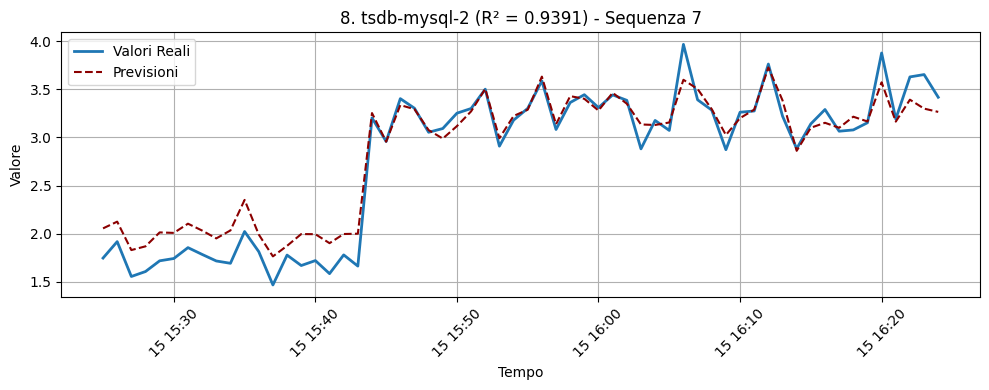

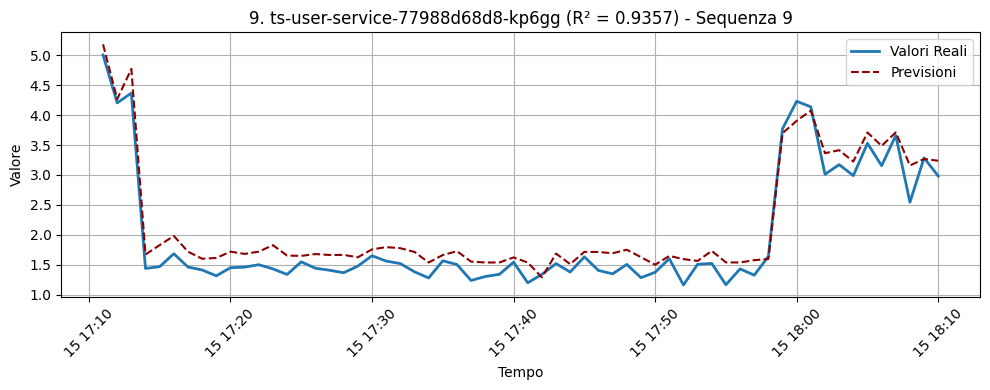

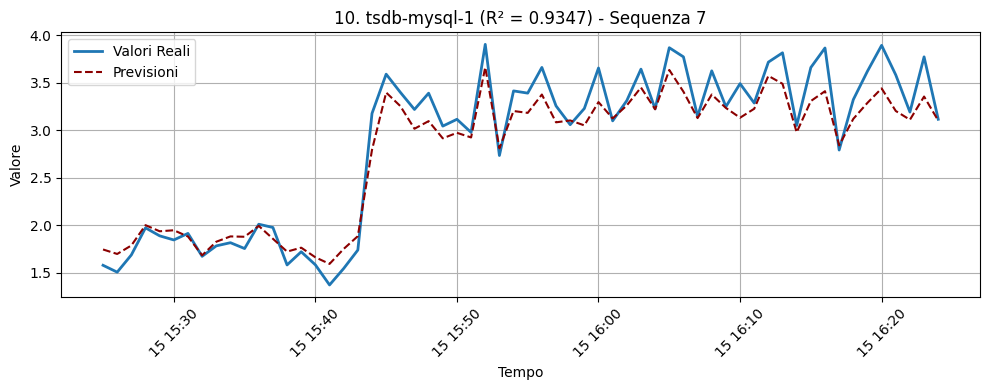

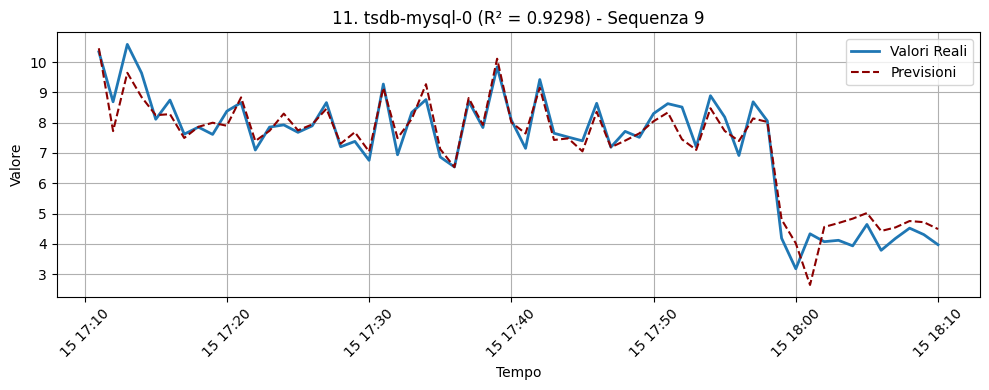

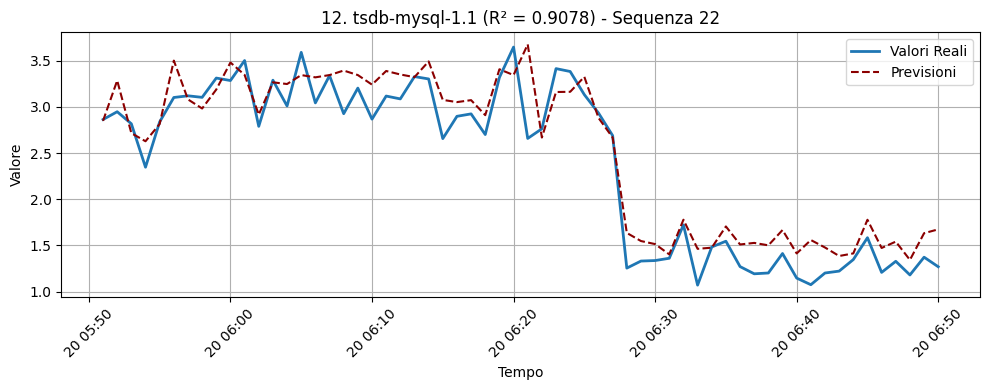

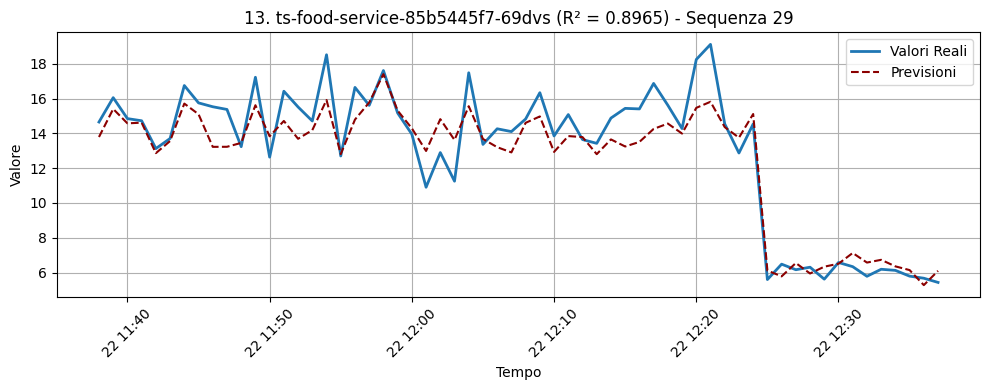

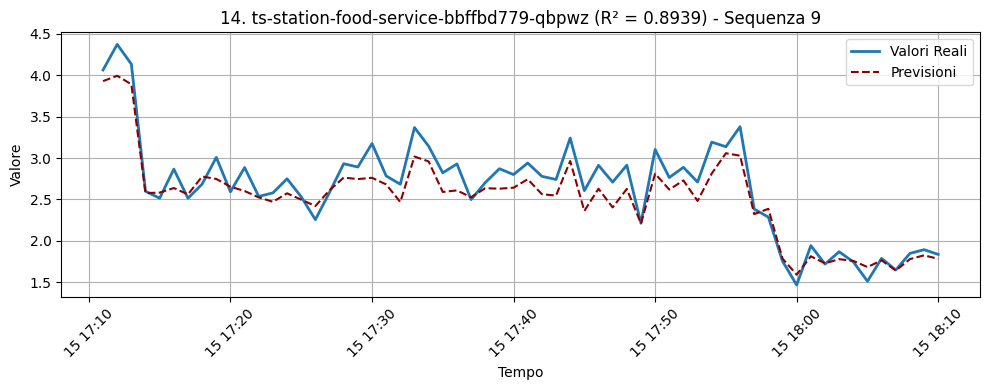

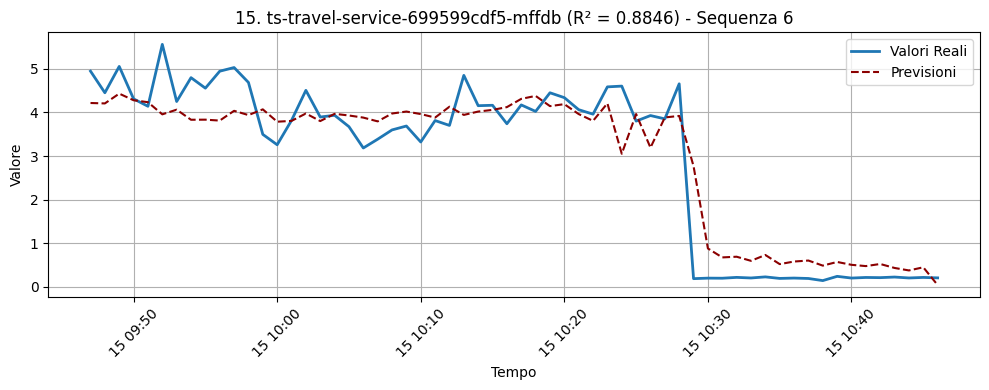

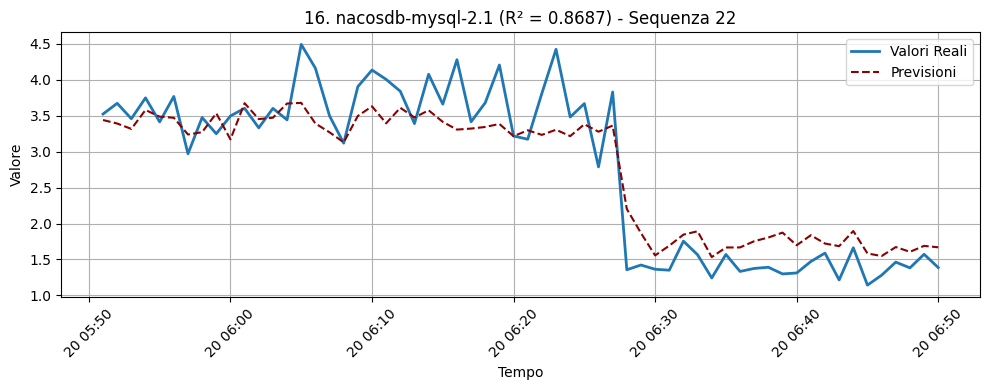

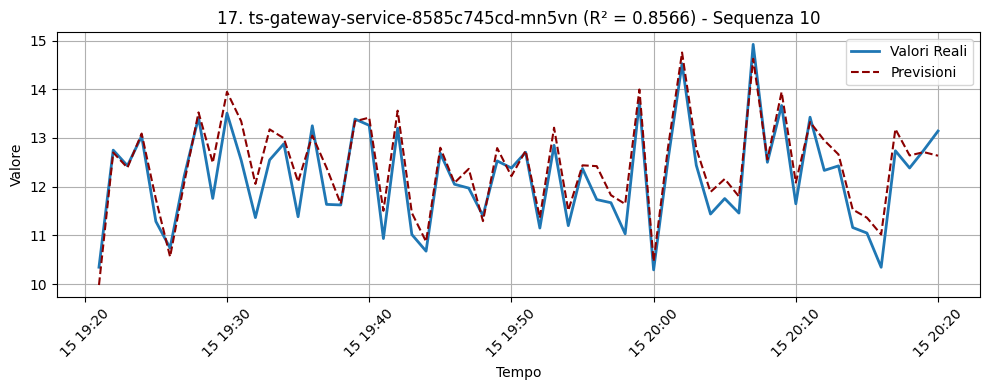

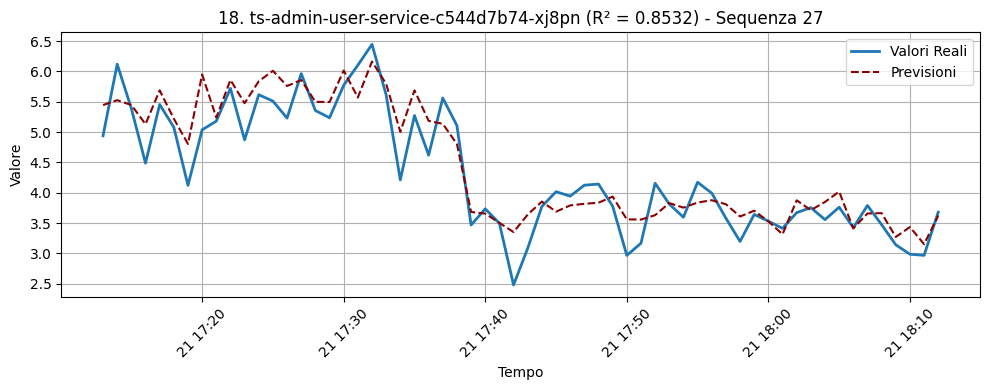

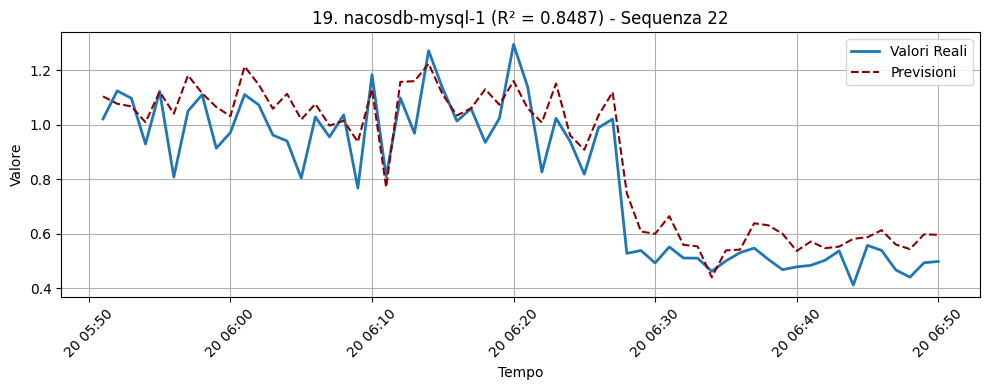

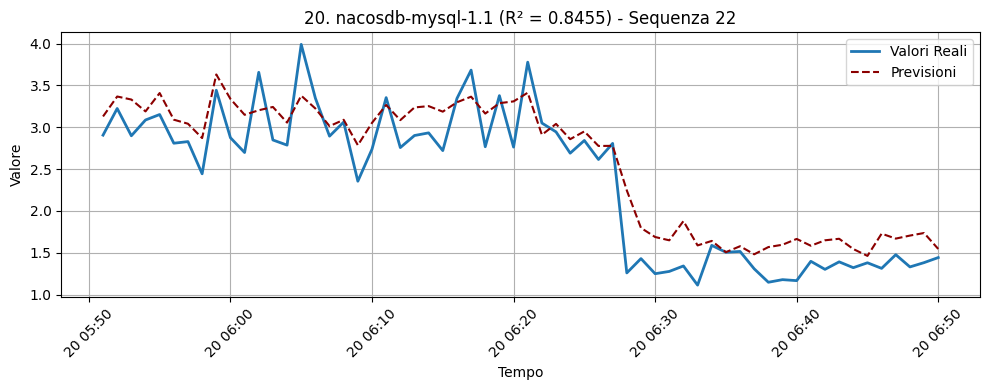

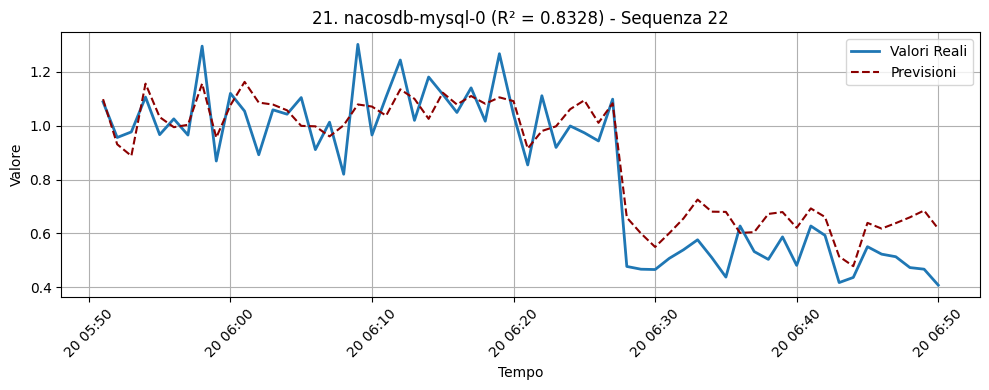

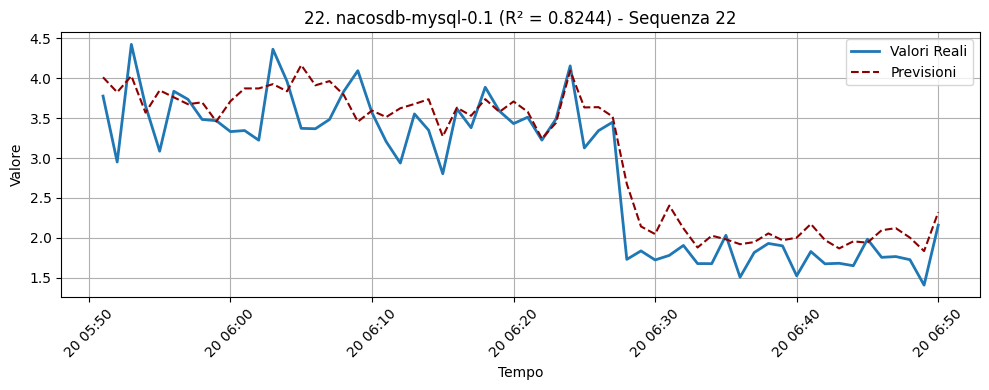

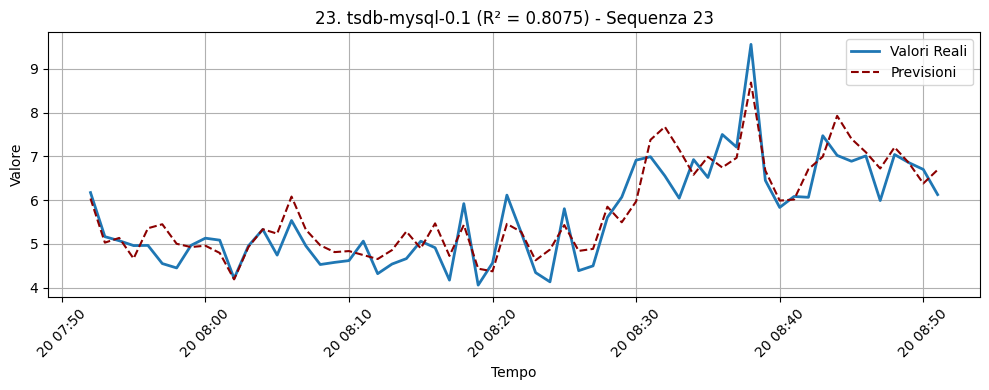

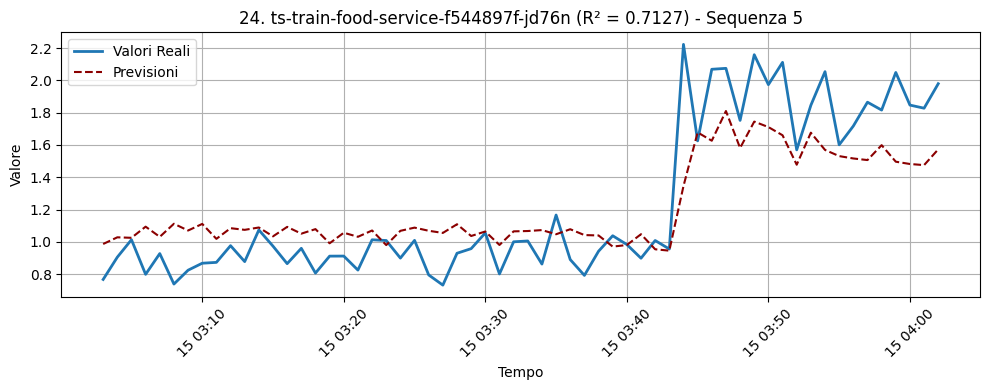

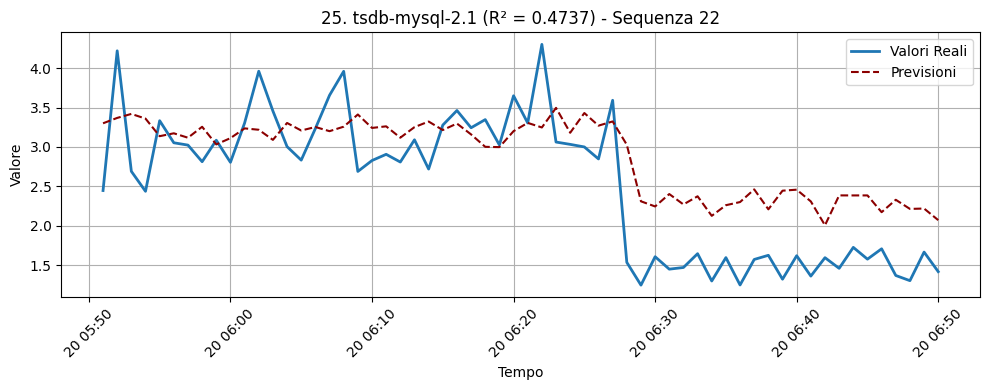

📊 Tutte le colonne predette (25 totali):
 Posizione                                 Colonna  Sequenza     R²
         1    ts-contacts-service-69864b9cd7-j7kng         9 0.9903
         2    ts-security-service-7fd5f9ff9c-k4nxj         9 0.9658
         3  ts-order-other-service-6666b4d4d-x6l64         7 0.9622
         4     ts-preserve-service-56dfc8d6d-vnlpb         7 0.9600
         5       ts-route-service-6f5855dc47-7ht8z        10 0.9559
         6                         nacosdb-mysql-2        22 0.9498
         7       ts-order-service-69885cc6c8-4mcjr         9 0.9397
         8                            tsdb-mysql-2         7 0.9391
         9        ts-user-service-77988d68d8-kp6gg         9 0.9357
        10                            tsdb-mysql-1         7 0.9347
        11                            tsdb-mysql-0         9 0.9298
        12                          tsdb-mysql-1.1        22 0.9078
        13         ts-food-service-85b5445f7-69dvs        29 0.8965
       

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score

# === Configurazioni ===
device = torch.device("cpu")  # Usa "cuda" se disponibile
top_predictions = []

# === Recupera le colonne da predire ===
columns_to_predict = sorted([
    name for name in os.listdir(base_output_path)
    if os.path.isdir(os.path.join(base_output_path, name))
])

# === Funzione per effettuare una previsione multi-step ===
def predict_sequence(model_path, seq, col, window_size, output_steps):
    # Scaling delle feature
    scaler_val = MinMaxScaler()
    valori_scaled = scaler_val.fit_transform(seq[col].values.reshape(-1, 1)).flatten()
    scaler_hour = MinMaxScaler()
    hours_scaled = scaler_hour.fit_transform(seq["hour"].values.reshape(-1, 1)).flatten()
    scaler_week = MinMaxScaler()
    weekdays_scaled = scaler_week.fit_transform(seq["weekday"].values.reshape(-1, 1)).flatten()

    # Carica modello migliorato
    model = ConvLSTMNetImproved(window_size=window_size).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Previsione step-by-step
    pred_input_v = valori_scaled[-(window_size + output_steps):]
    pred_input_h = hours_scaled[-(window_size + output_steps):]
    pred_input_d = weekdays_scaled[-(window_size + output_steps):]

    predicted_scaled = []
    for step in range(output_steps):
        window_v = pred_input_v[step:step + window_size]
        window_h = pred_input_h[step:step + window_size]
        window_d = pred_input_d[step:step + window_size]

        if len(window_v) == window_size:
            input_seq = np.stack([window_v, window_h, window_d], axis=-1).reshape(1, window_size, 3)
            input_tensor = torch.tensor(input_seq, dtype=torch.float32).to(device)

            with torch.no_grad():
                pred = model(input_tensor).cpu().numpy().flatten()[0]
            predicted_scaled.append(pred)

    if len(predicted_scaled) < output_steps:
        return None

    predicted_real = scaler_val.inverse_transform(np.array(predicted_scaled).reshape(-1, 1)).flatten()
    real_values = seq[col].iloc[-output_steps:]
    last_times = seq["Time"].iloc[-output_steps:]

    r2 = r2_score(real_values, predicted_real)

    return {
        "col": col,
        "r2": r2,
        "pred": predicted_real,
        "real": real_values,
        "time": last_times
    }

# === Loop principale: colonne × sequenze ===
for col in columns_to_predict:
    model_path = os.path.join(base_output_path, col, f"model_{col}.pt")
    if not os.path.exists(model_path):
        continue

    best_r2 = -np.inf
    best_result = None

    for seq_id, seq in enumerate(sequenze):
        if col not in seq.columns:
            continue

        result = predict_sequence(model_path, seq, col, window_size, output_steps)
        if result and result["r2"] > best_r2:
            best_r2 = result["r2"]
            best_result = result
            best_result["seq_id"] = seq_id

    if best_result:
        top_predictions.append(best_result)

# === Ordina le predizioni per R² decrescente ===
top_predictions.sort(key=lambda x: x["r2"], reverse=True)

# === Plot risultati ===
for idx, entry in enumerate(top_predictions, 1):
    plt.figure(figsize=(10, 4))
    plt.plot(entry["time"], entry["real"], label="Valori Reali", linewidth=2)
    plt.plot(entry["time"], entry["pred"], label="Previsioni", linestyle="--", color="darkred")
    plt.title(f"{idx}. {entry['col']} (R² = {entry['r2']:.4f}) - Sequenza {entry['seq_id']+1}")
    plt.xlabel("Tempo")
    plt.ylabel("Valore")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.grid(True)
    plt.show()

# === Tabella finale dei risultati ===
tabella_risultati = pd.DataFrame([{
    "Posizione": i + 1,
    "Colonna": entry["col"],
    "Sequenza": entry["seq_id"] + 1,
    "R²": round(entry["r2"], 4)
} for i, entry in enumerate(top_predictions)])

print(f"📊 Tutte le colonne predette ({len(top_predictions)} totali):")
print(tabella_risultati.to_string(index=False))

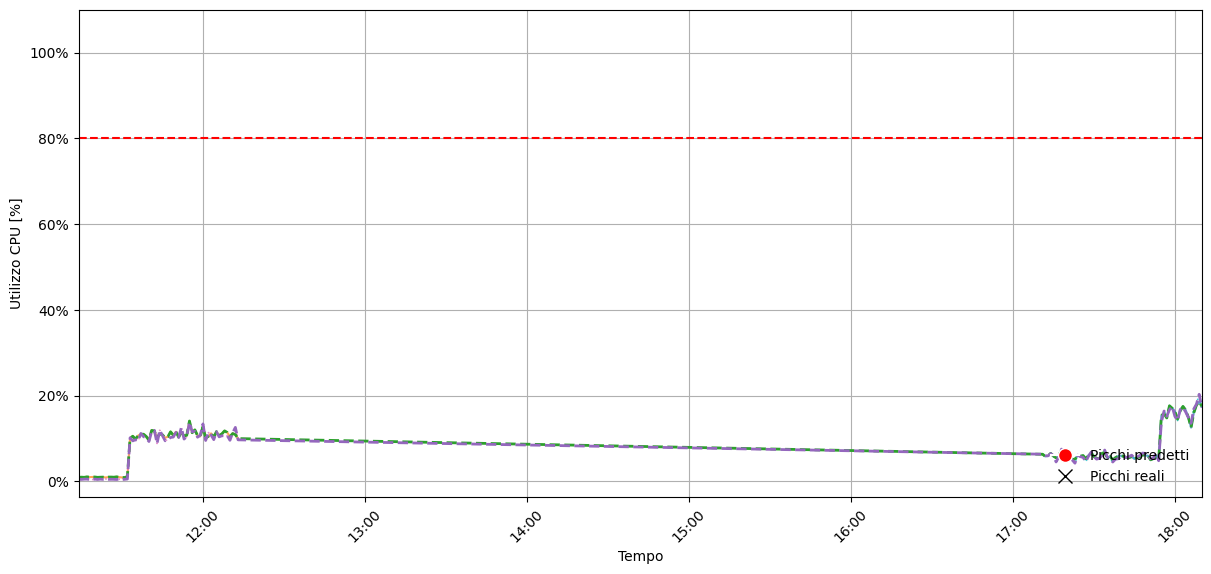

Microservizi: ts-contacts-service-69864b9cd7-j7kng & ts-admin-user-service-c544d7b74-xj8pn
Precision: 0.00, Recall: 0.00, F1: 0.00


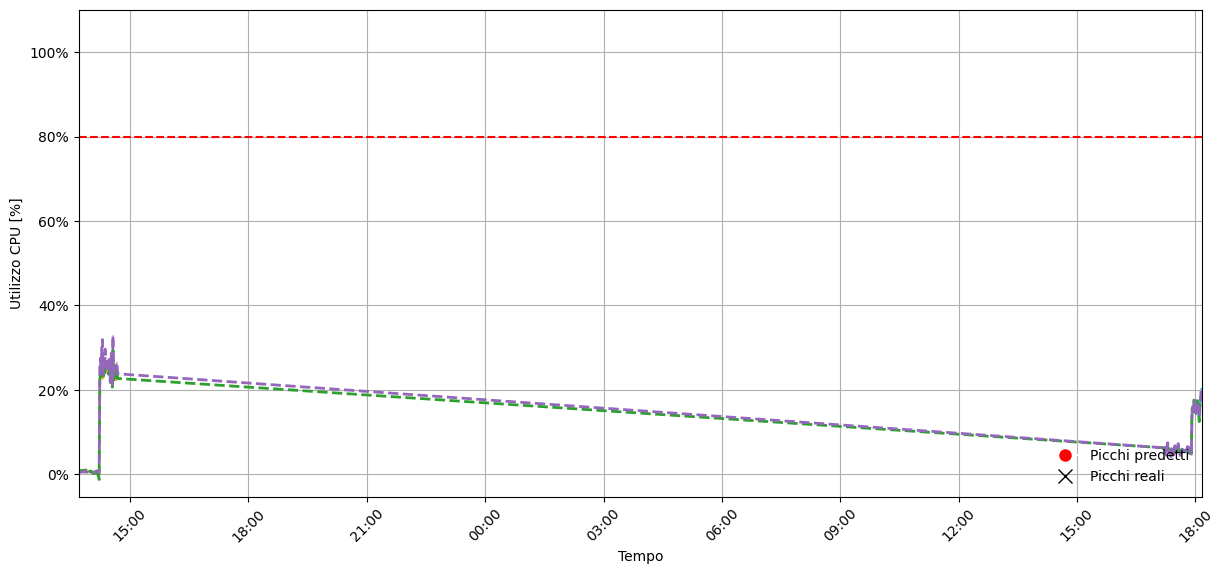

Microservizi: ts-contacts-service-69864b9cd7-j7kng & ts-preserve-service-56dfc8d6d-vnlpb
Precision: 0.00, Recall: 0.00, F1: 0.00


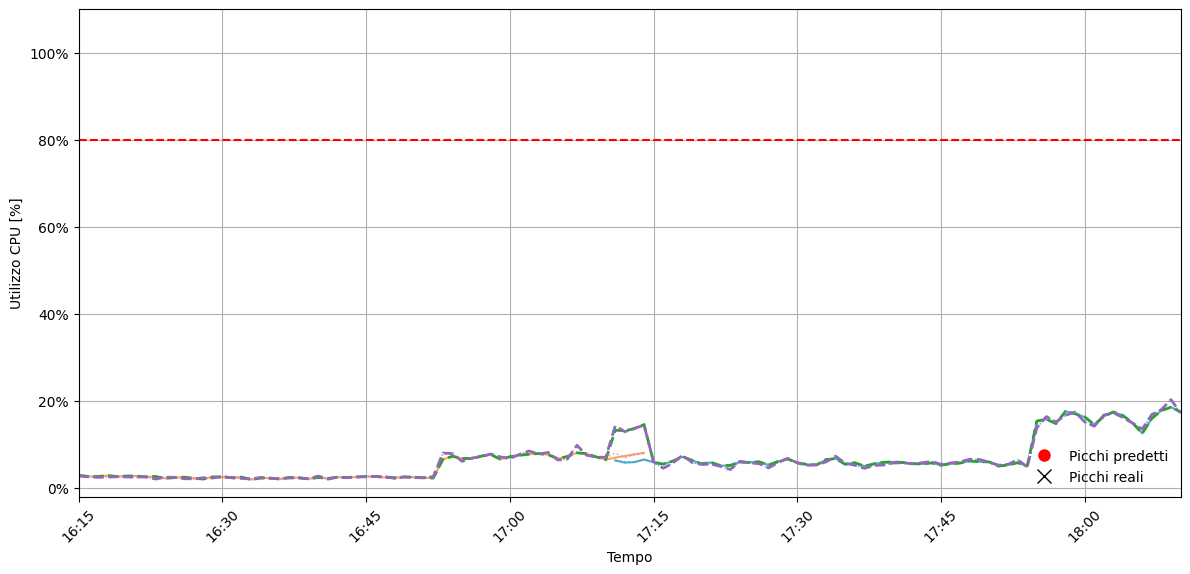

Microservizi: ts-contacts-service-69864b9cd7-j7kng & ts-station-food-service-bbffbd779-qbpwz
Precision: 0.00, Recall: 0.00, F1: 0.00


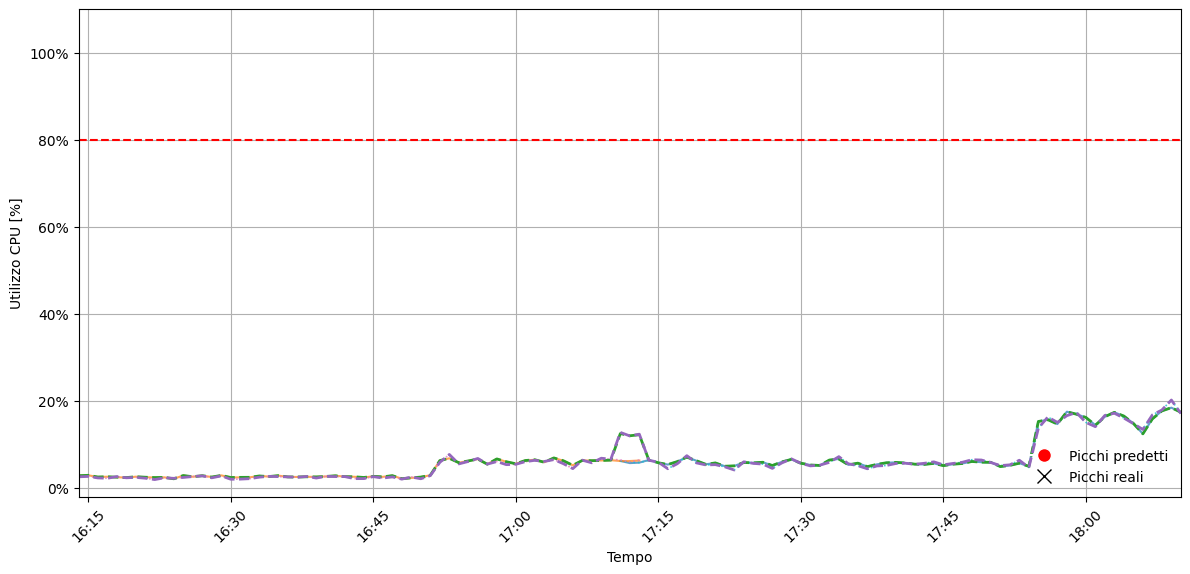

Microservizi: ts-contacts-service-69864b9cd7-j7kng & ts-route-service-6f5855dc47-7ht8z
Precision: 0.00, Recall: 0.00, F1: 0.00


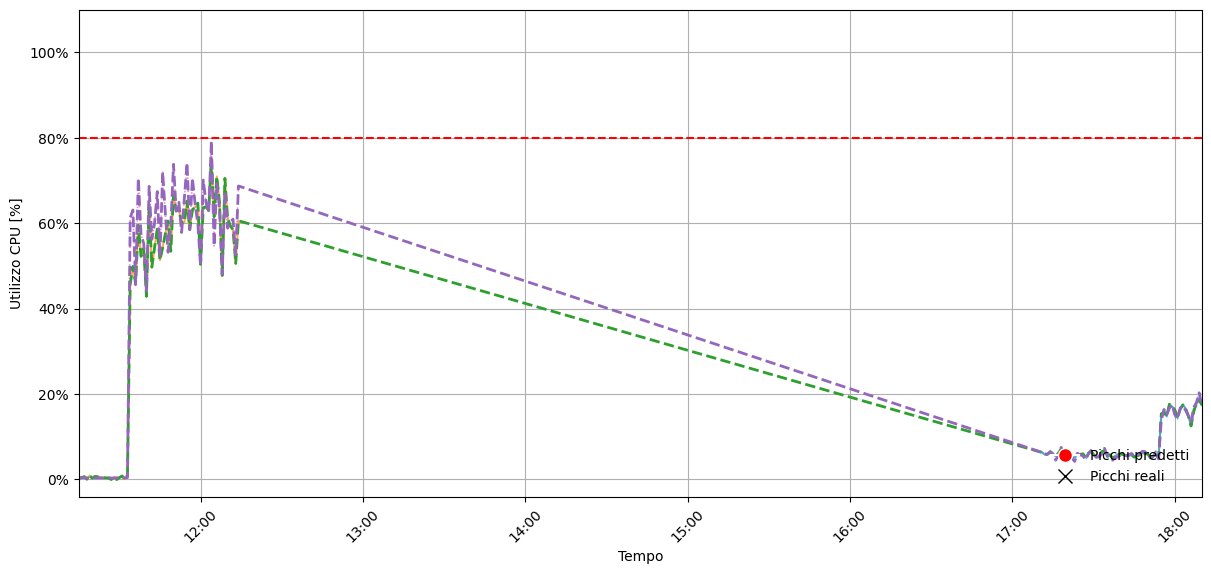

Microservizi: ts-contacts-service-69864b9cd7-j7kng & ts-travel-service-699599cdf5-mffdb
Precision: 0.00, Recall: 0.00, F1: 0.00


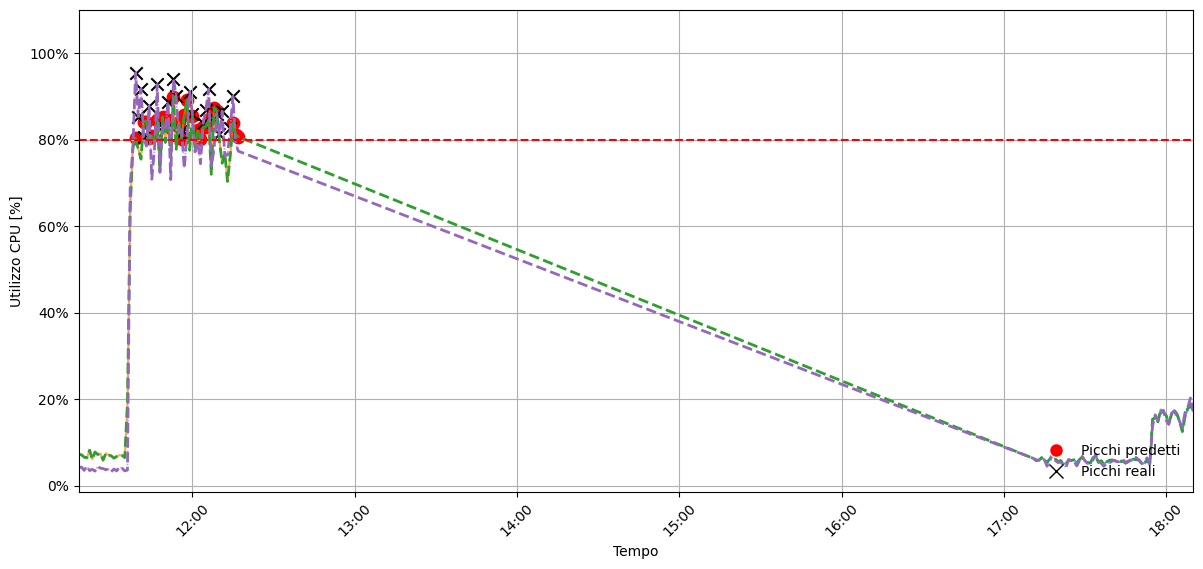

Microservizi: ts-contacts-service-69864b9cd7-j7kng & ts-gateway-service-8585c745cd-mn5vn
Precision: 1.00, Recall: 1.00, F1: 1.00


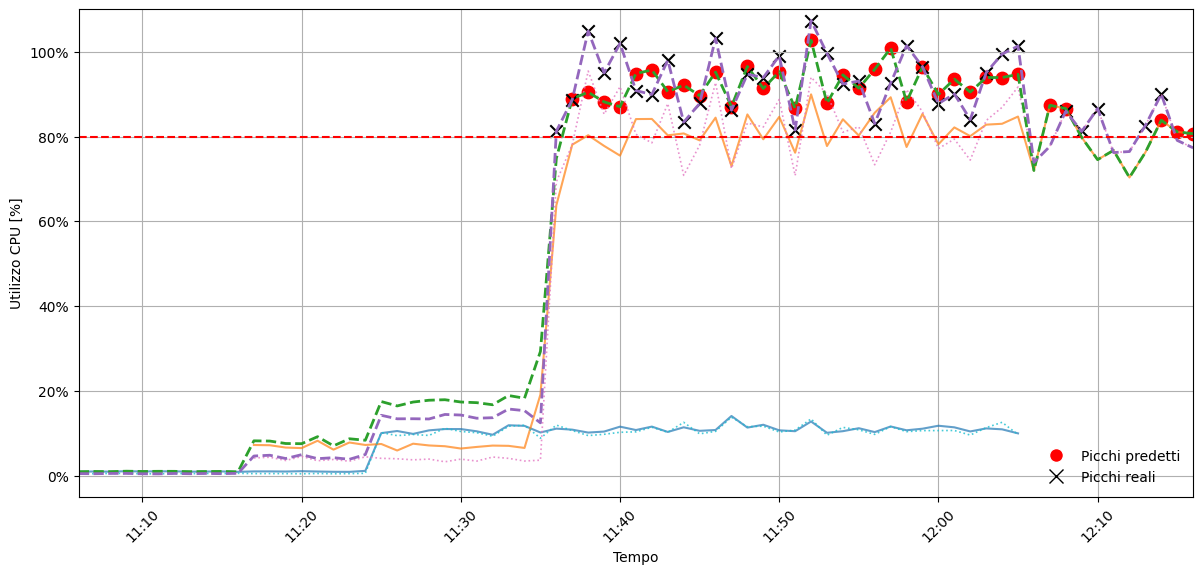

Microservizi: ts-admin-user-service-c544d7b74-xj8pn & ts-gateway-service-8585c745cd-mn5vn
Precision: 1.00, Recall: 0.97, F1: 0.99


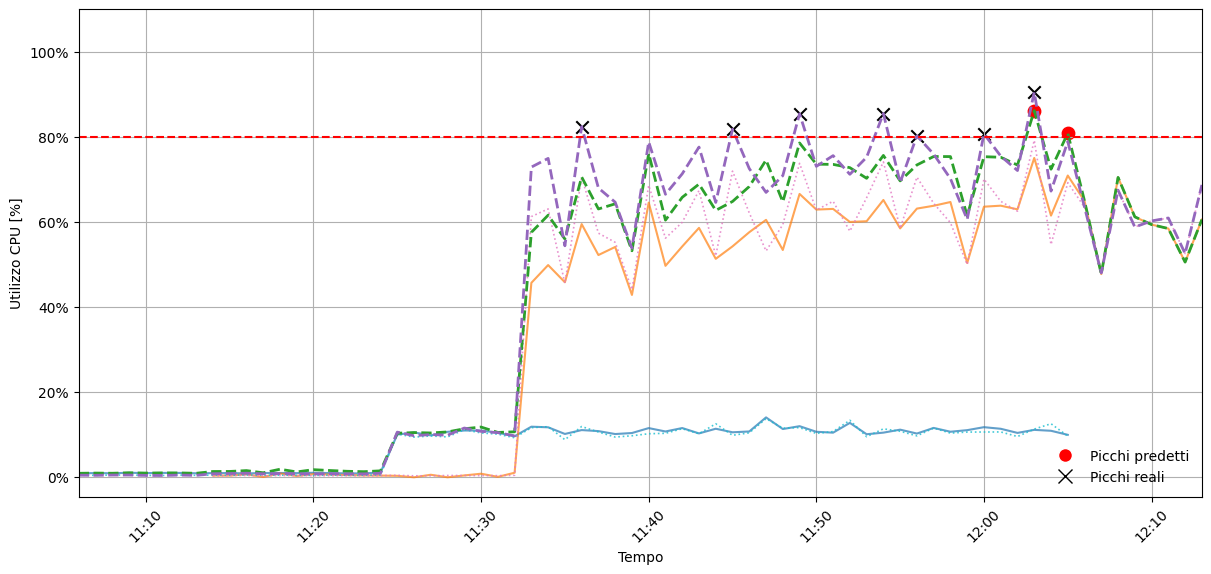

Microservizi: ts-admin-user-service-c544d7b74-xj8pn & ts-travel-service-699599cdf5-mffdb
Precision: 1.00, Recall: 0.29, F1: 0.44


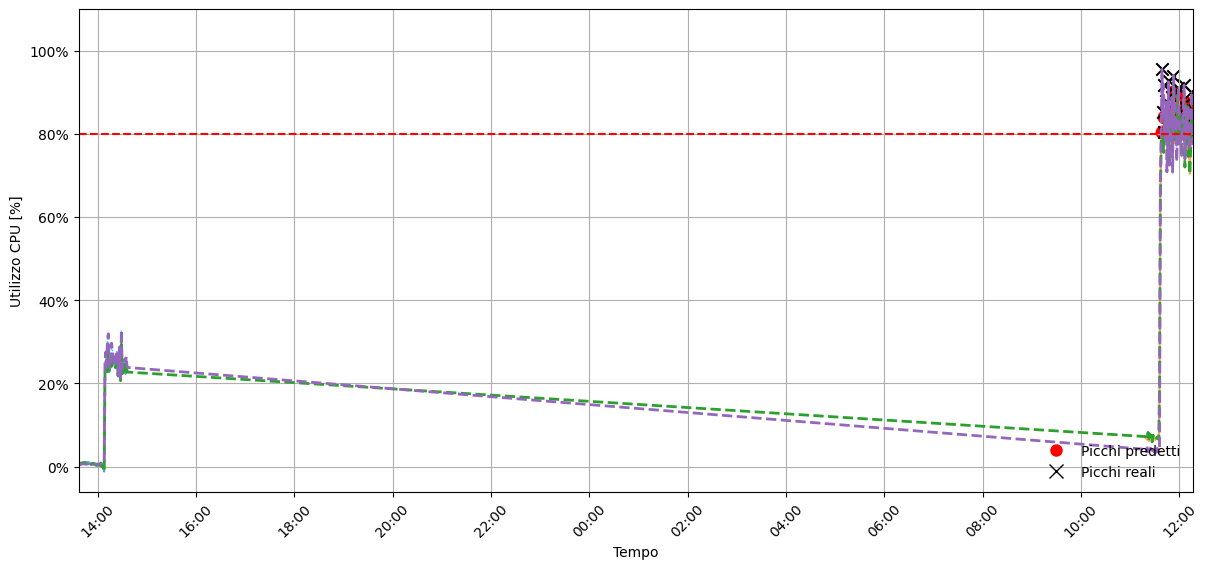

Microservizi: ts-preserve-service-56dfc8d6d-vnlpb & ts-gateway-service-8585c745cd-mn5vn
Precision: 1.00, Recall: 1.00, F1: 1.00


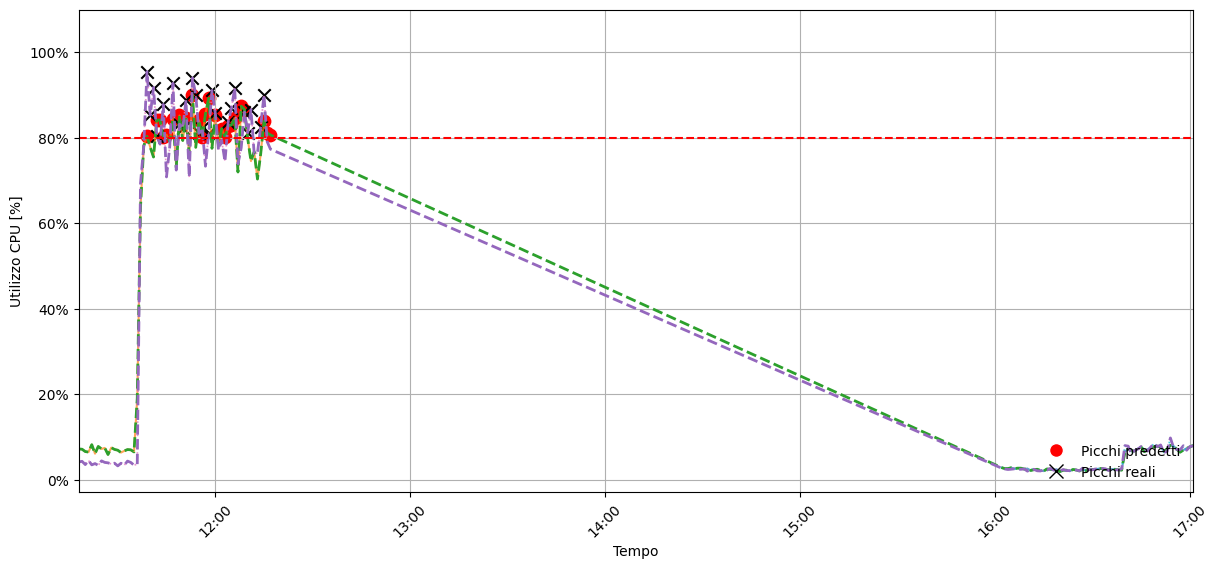

Microservizi: ts-station-food-service-bbffbd779-qbpwz & ts-gateway-service-8585c745cd-mn5vn
Precision: 1.00, Recall: 1.00, F1: 1.00


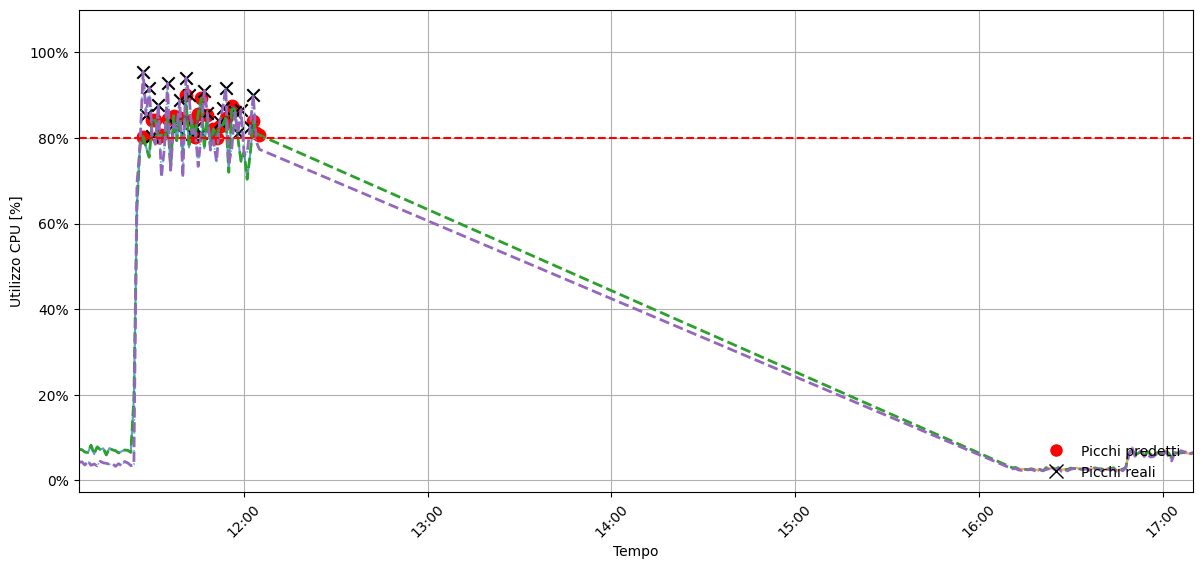

Microservizi: ts-gateway-service-8585c745cd-mn5vn & ts-route-service-6f5855dc47-7ht8z
Precision: 1.00, Recall: 1.00, F1: 1.00


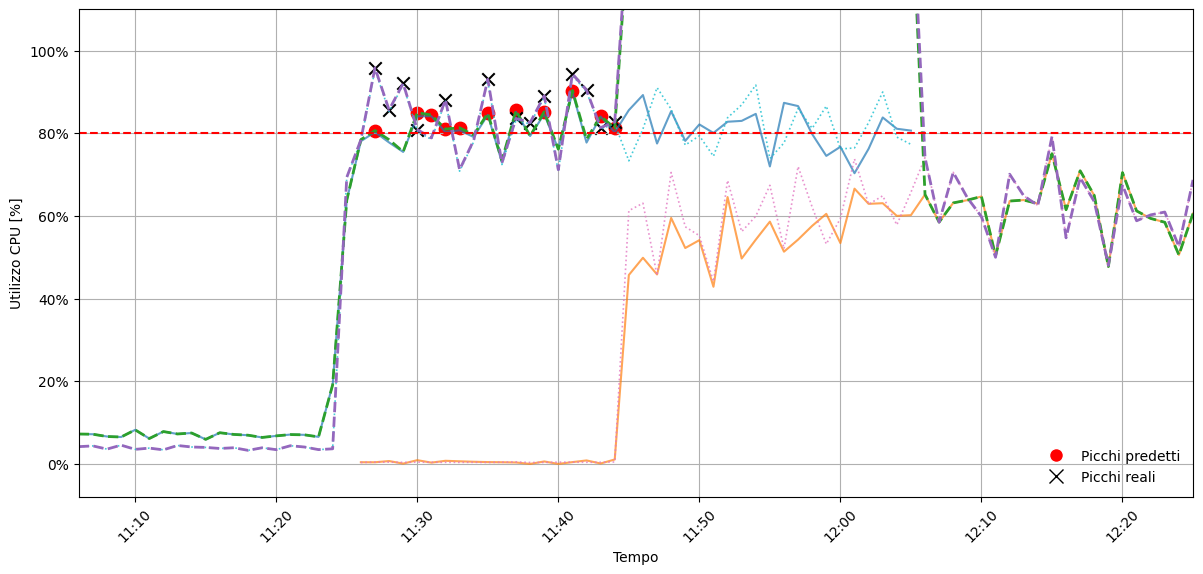

Microservizi: ts-gateway-service-8585c745cd-mn5vn & ts-travel-service-699599cdf5-mffdb
Precision: 1.00, Recall: 0.94, F1: 0.97


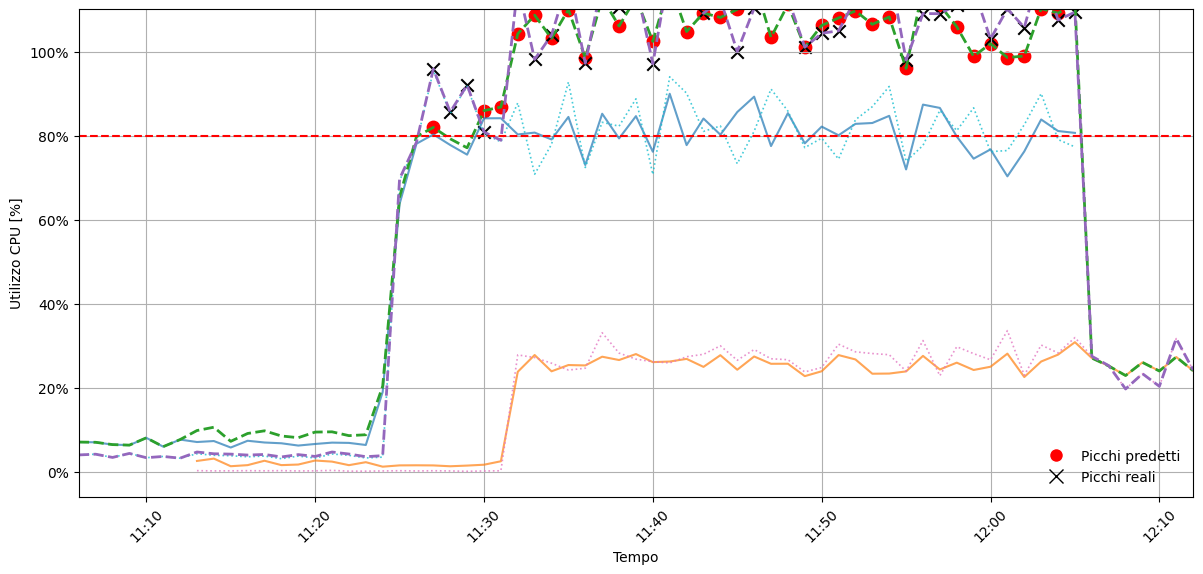

Microservizi: ts-gateway-service-8585c745cd-mn5vn & ts-food-service-85b5445f7-69dvs
Precision: 1.00, Recall: 0.97, F1: 0.99


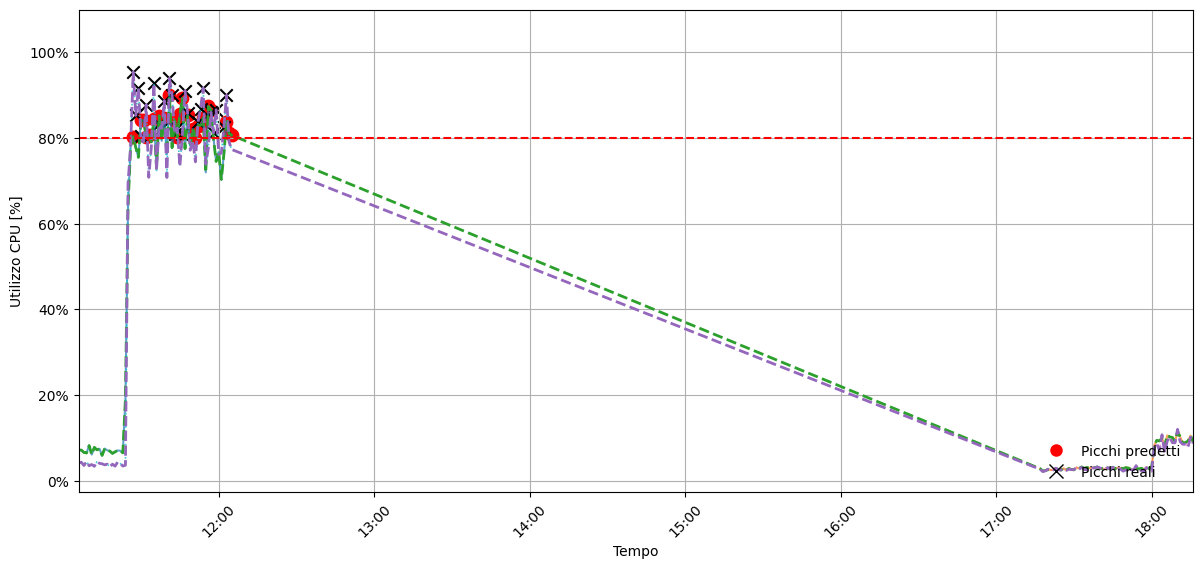

Microservizi: ts-gateway-service-8585c745cd-mn5vn & ts-order-service-69885cc6c8-4mcjr
Precision: 1.00, Recall: 1.00, F1: 1.00


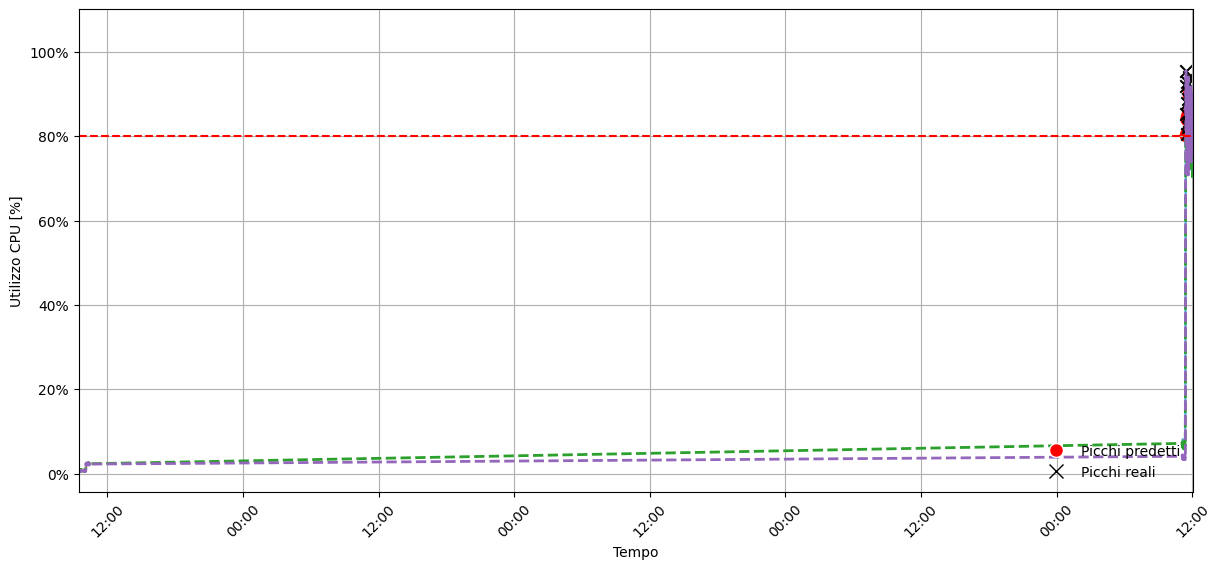

Microservizi: ts-gateway-service-8585c745cd-mn5vn & nacosdb-mysql-2
Precision: 1.00, Recall: 1.00, F1: 1.00


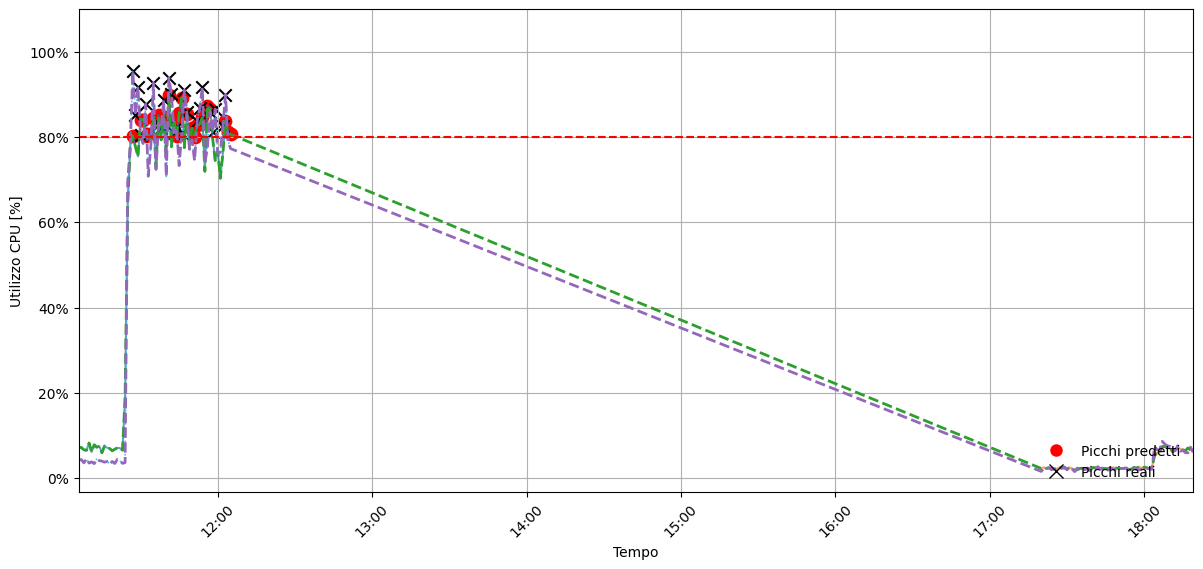

Microservizi: ts-gateway-service-8585c745cd-mn5vn & ts-security-service-7fd5f9ff9c-k4nxj
Precision: 1.00, Recall: 1.00, F1: 1.00


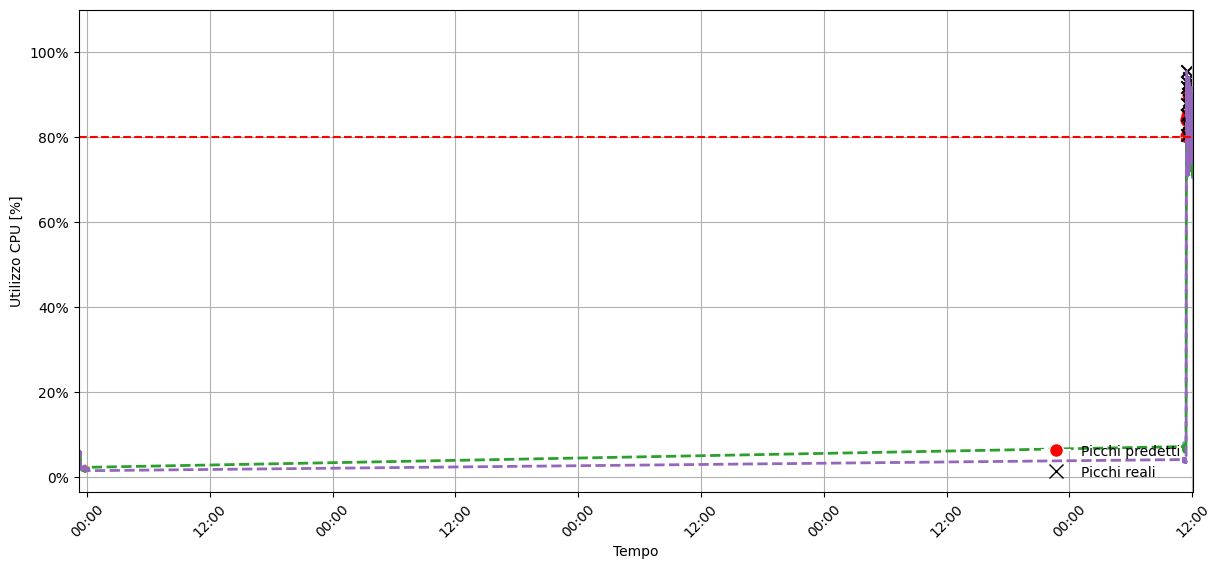

Microservizi: ts-gateway-service-8585c745cd-mn5vn & tsdb-mysql-0
Precision: 1.00, Recall: 1.00, F1: 1.00


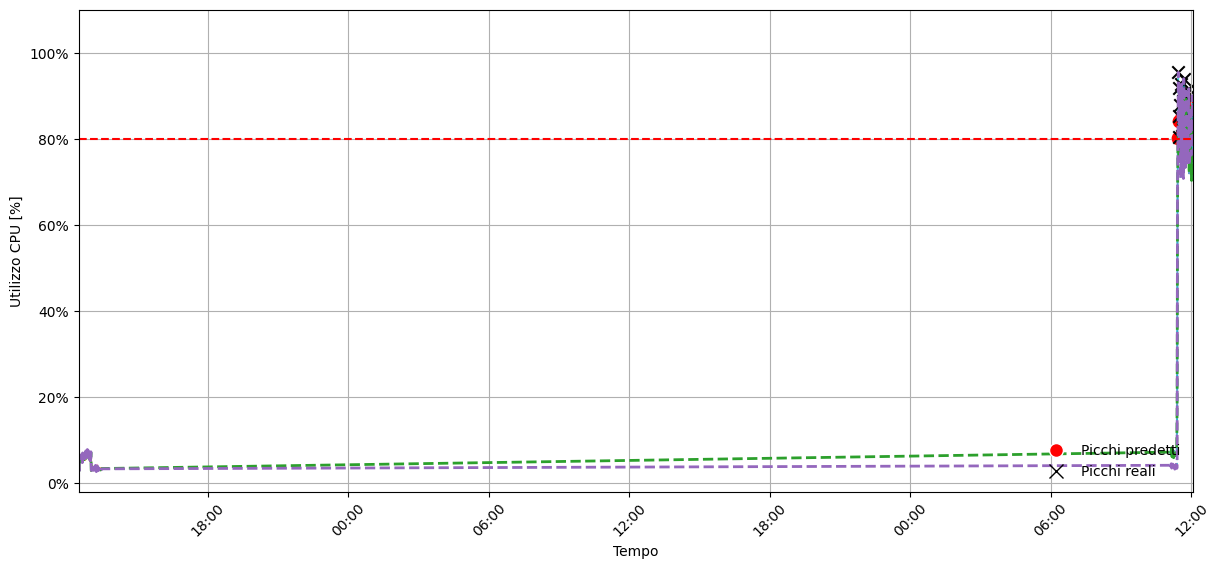

Microservizi: ts-gateway-service-8585c745cd-mn5vn & tsdb-mysql-1
Precision: 1.00, Recall: 1.00, F1: 1.00


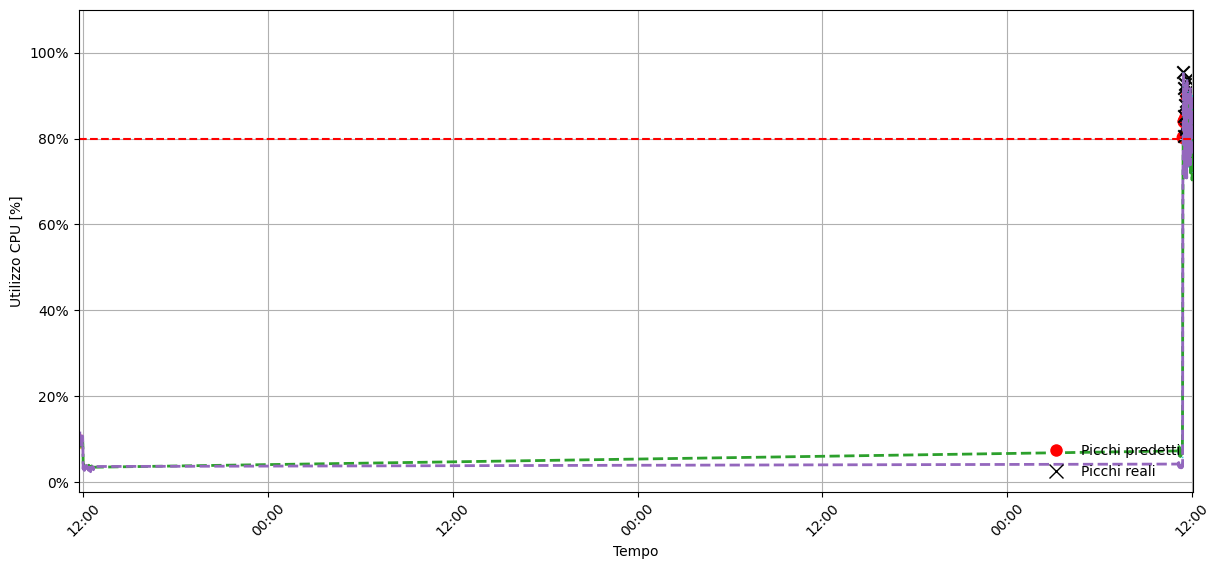

Microservizi: ts-gateway-service-8585c745cd-mn5vn & tsdb-mysql-2
Precision: 1.00, Recall: 1.00, F1: 1.00


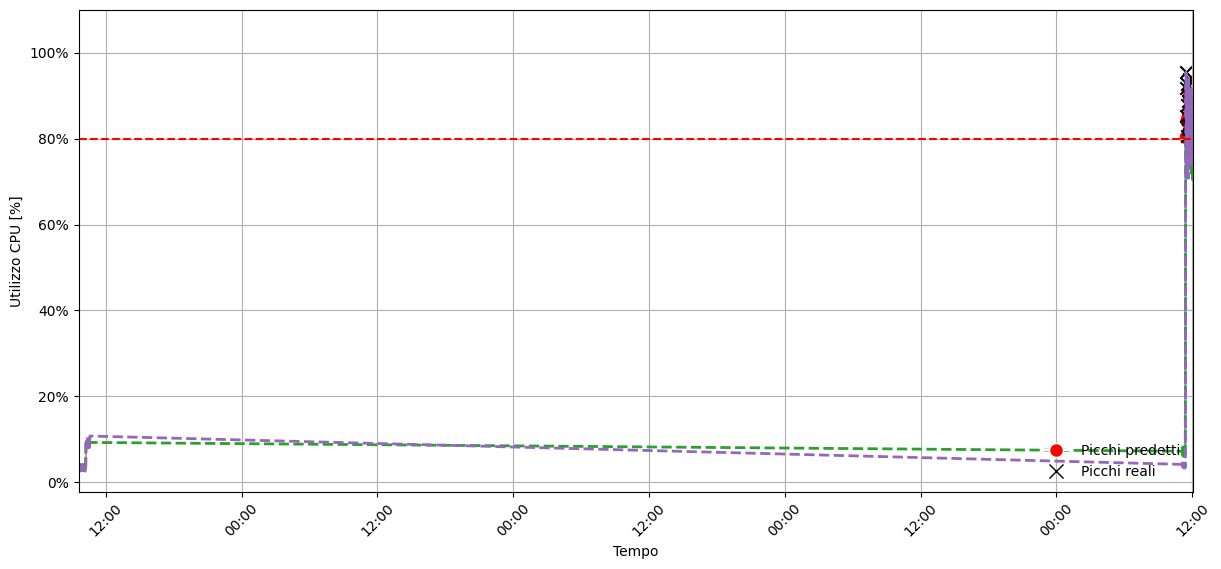

Microservizi: ts-gateway-service-8585c745cd-mn5vn & tsdb-mysql-0.1
Precision: 1.00, Recall: 1.00, F1: 1.00


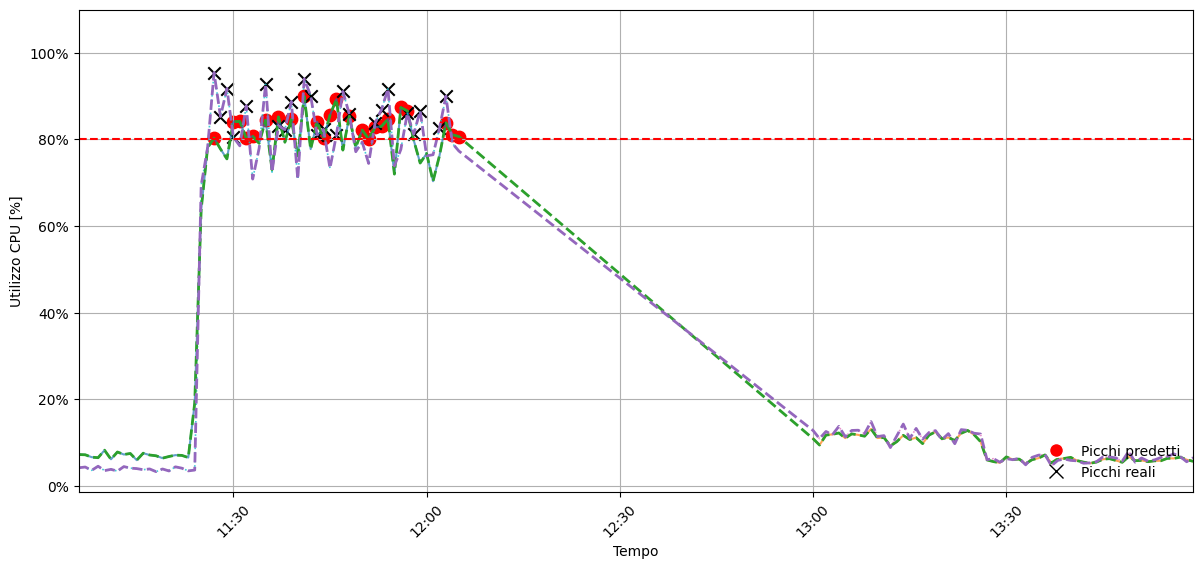

Microservizi: ts-gateway-service-8585c745cd-mn5vn & ts-order-other-service-6666b4d4d-x6l64
Precision: 1.00, Recall: 1.00, F1: 1.00


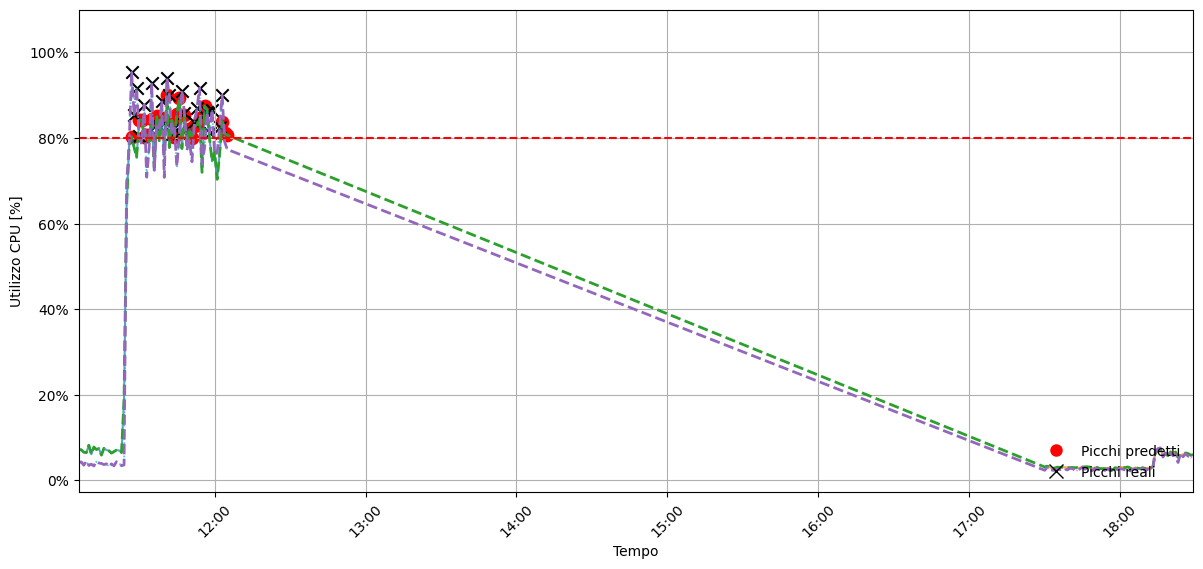

Microservizi: ts-gateway-service-8585c745cd-mn5vn & ts-user-service-77988d68d8-kp6gg
Precision: 1.00, Recall: 1.00, F1: 1.00


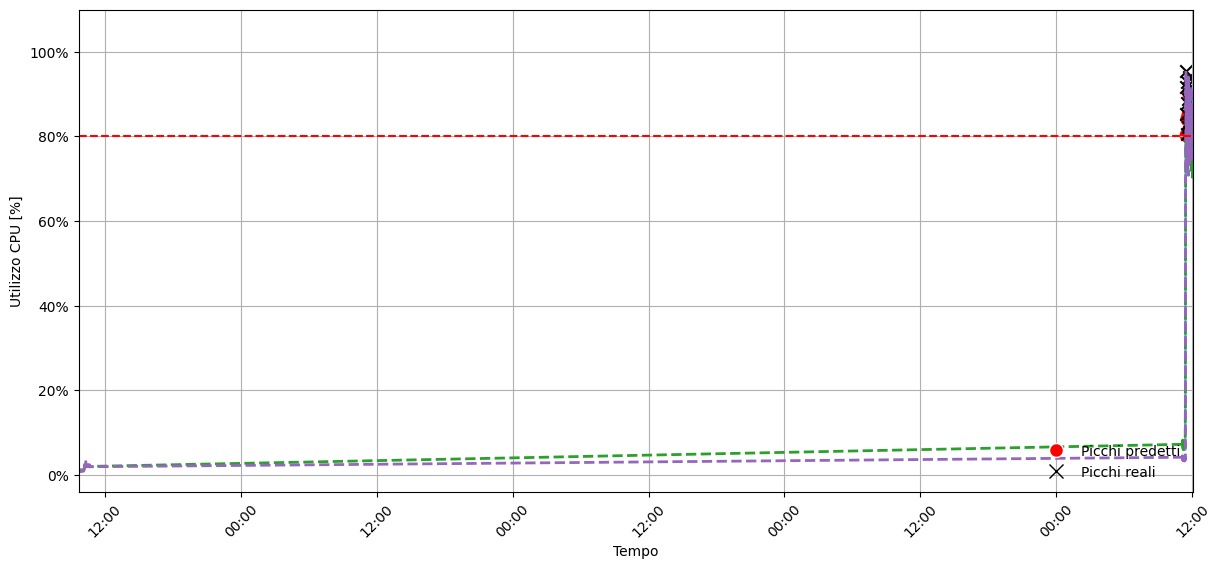

Microservizi: ts-gateway-service-8585c745cd-mn5vn & nacosdb-mysql-0
Precision: 1.00, Recall: 1.00, F1: 1.00


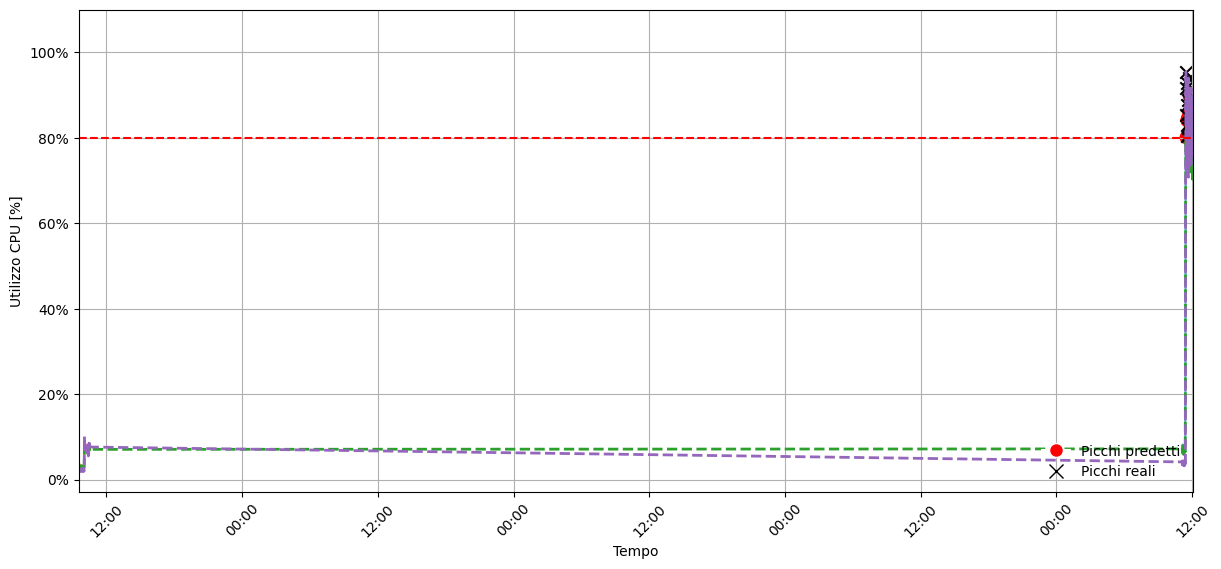

Microservizi: ts-gateway-service-8585c745cd-mn5vn & nacosdb-mysql-1.1
Precision: 1.00, Recall: 1.00, F1: 1.00


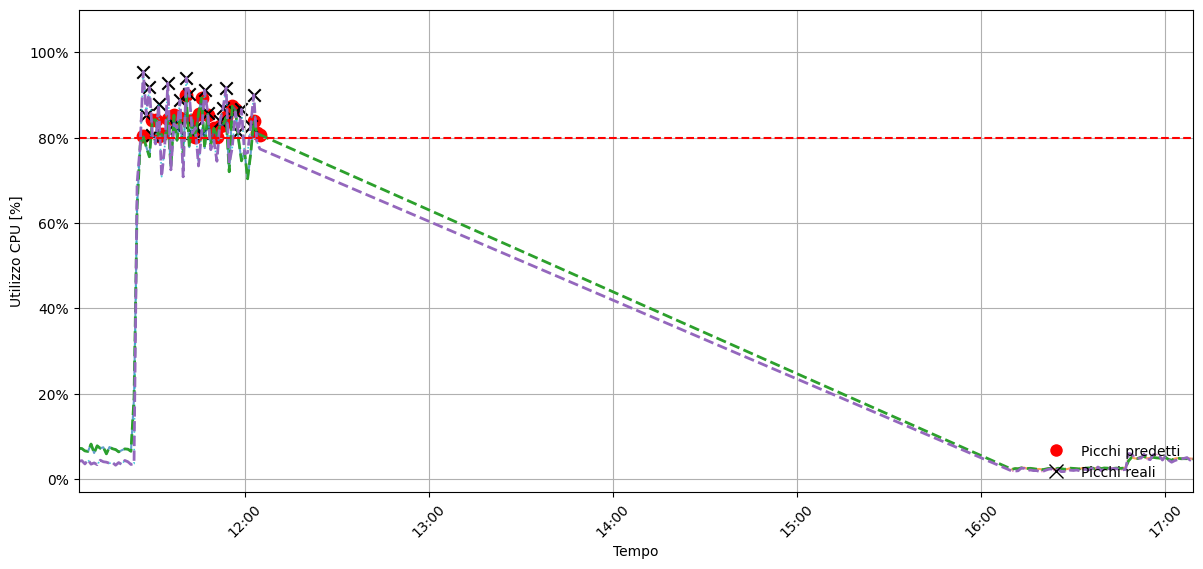

Microservizi: ts-gateway-service-8585c745cd-mn5vn & ts-train-food-service-f544897f-jd76n
Precision: 1.00, Recall: 1.00, F1: 1.00


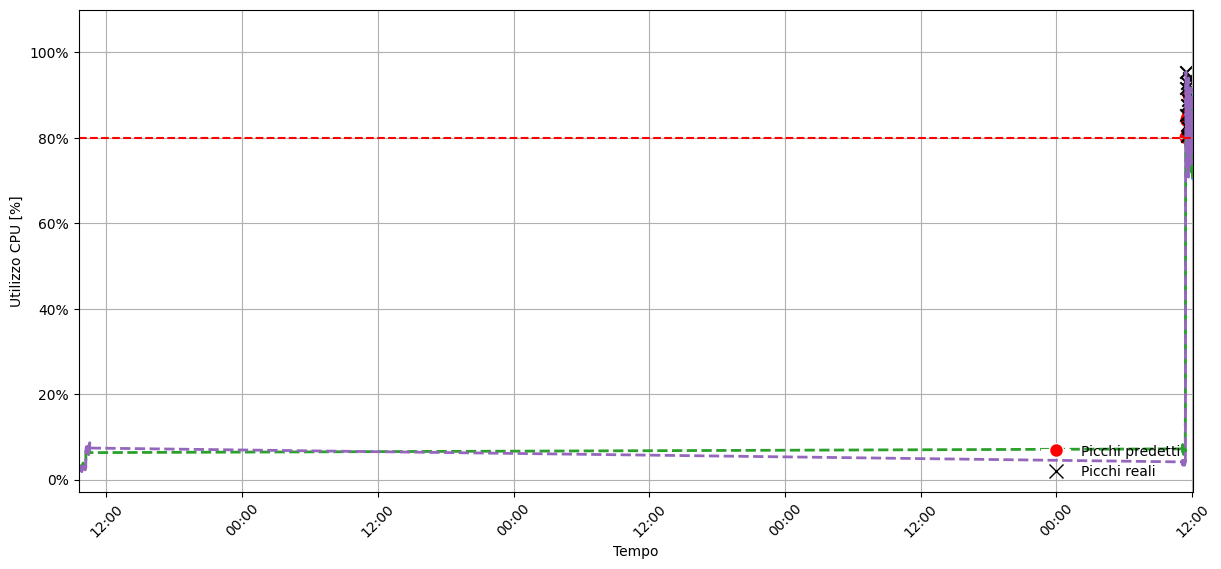

Microservizi: ts-gateway-service-8585c745cd-mn5vn & tsdb-mysql-2.1
Precision: 1.00, Recall: 1.00, F1: 1.00


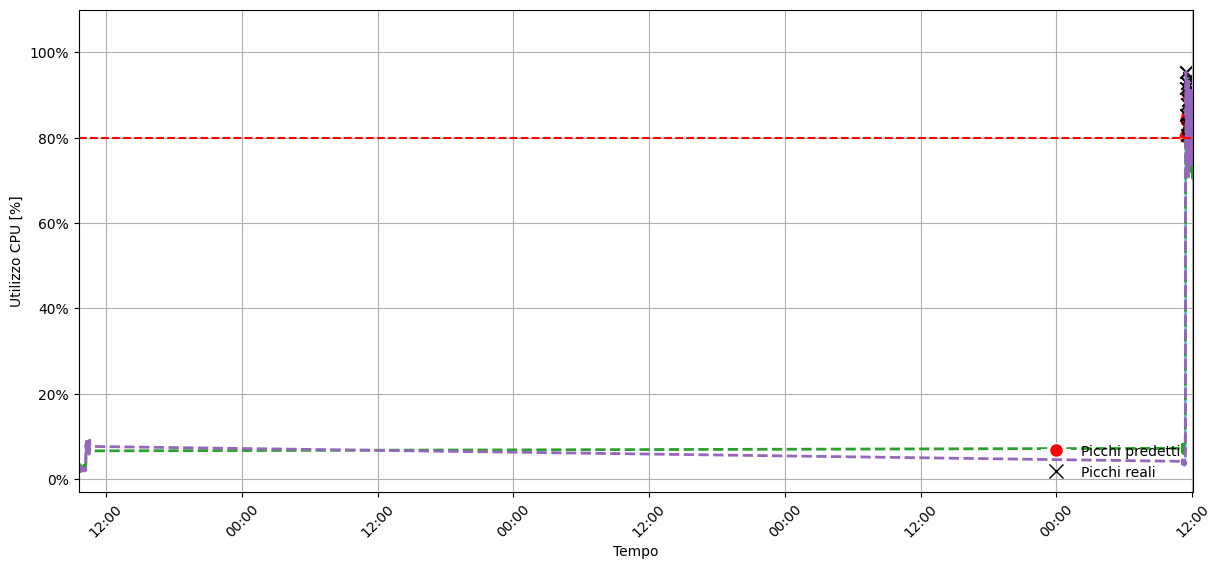

Microservizi: ts-gateway-service-8585c745cd-mn5vn & tsdb-mysql-1.1
Precision: 1.00, Recall: 1.00, F1: 1.00


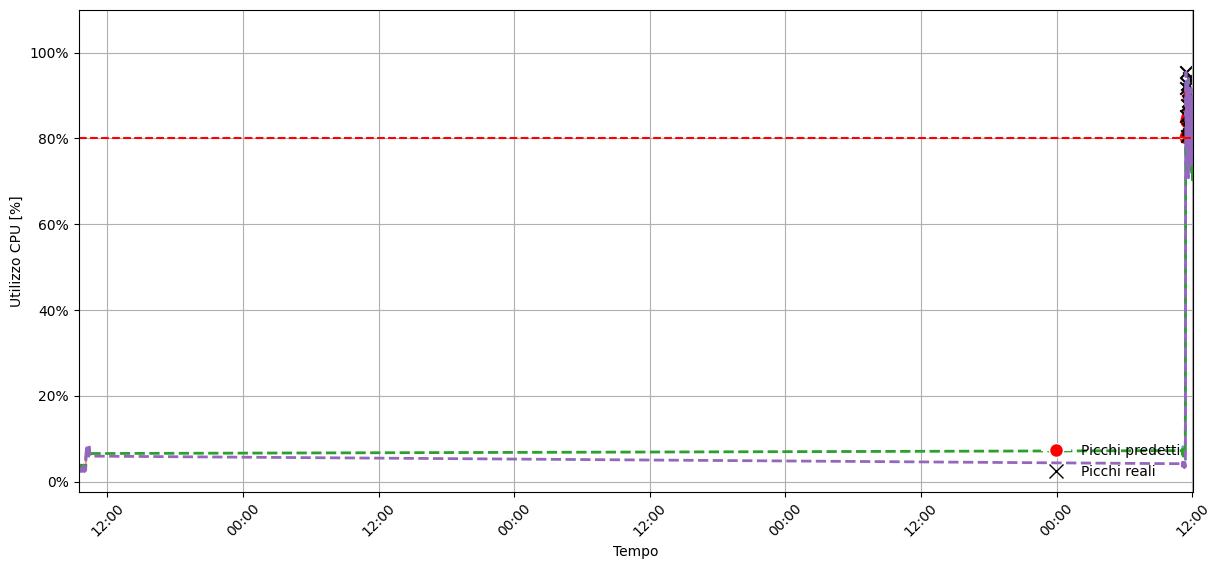

Microservizi: ts-gateway-service-8585c745cd-mn5vn & nacosdb-mysql-2.1
Precision: 1.00, Recall: 1.00, F1: 1.00


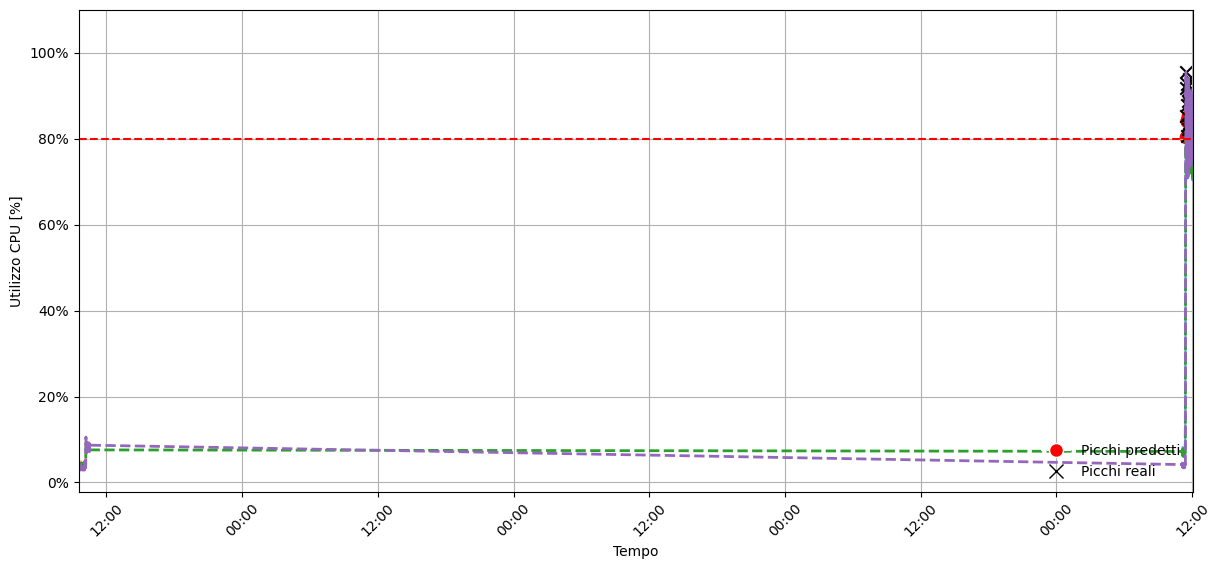

Microservizi: ts-gateway-service-8585c745cd-mn5vn & nacosdb-mysql-0.1
Precision: 1.00, Recall: 1.00, F1: 1.00


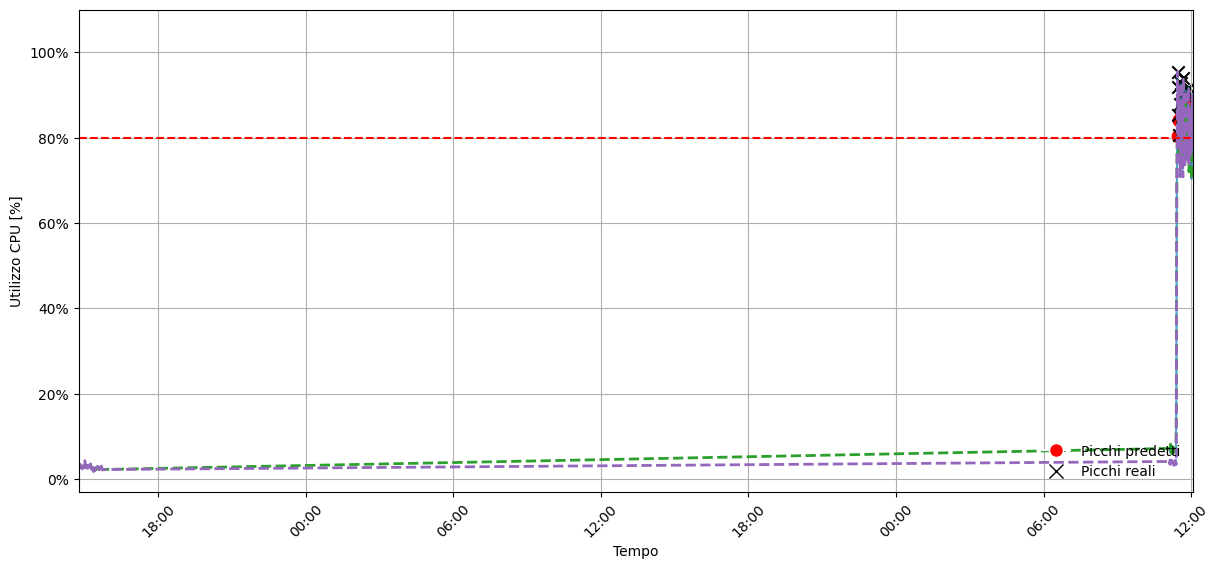

Microservizi: ts-gateway-service-8585c745cd-mn5vn & nacosdb-mysql-1
Precision: 1.00, Recall: 1.00, F1: 1.00


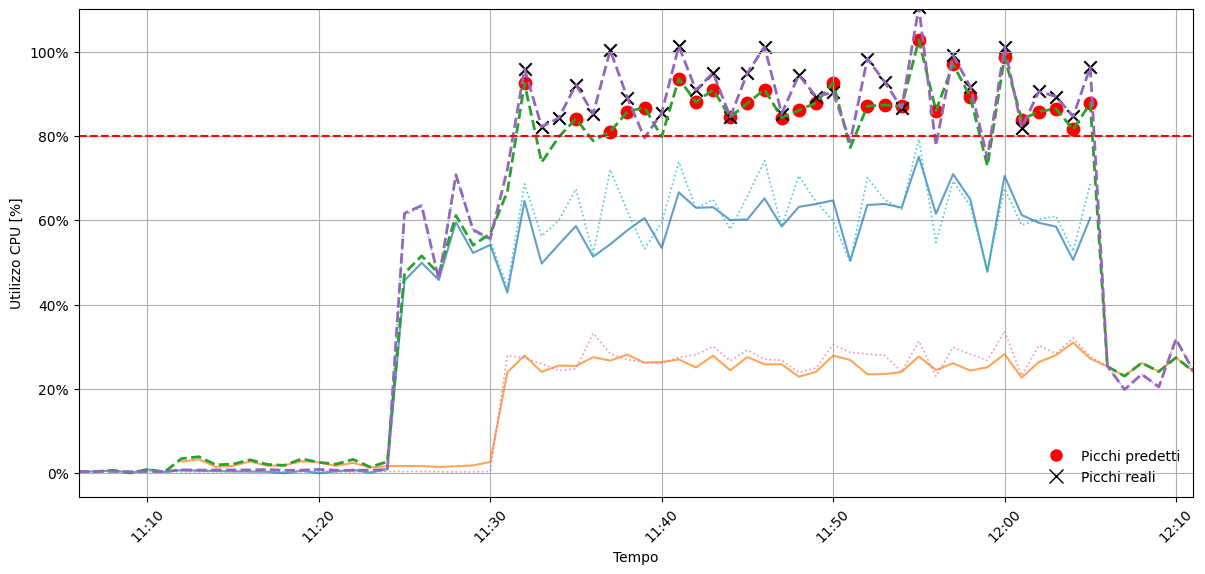

Microservizi: ts-travel-service-699599cdf5-mffdb & ts-food-service-85b5445f7-69dvs
Precision: 1.00, Recall: 0.93, F1: 0.97
                                                                         Pair  Precision   Recall  F1 Score
   ts-contacts-service-69864b9cd7-j7kng & ts-gateway-service-8585c745cd-mn5vn        1.0 1.000000  1.000000
  ts-admin-user-service-c544d7b74-xj8pn & ts-gateway-service-8585c745cd-mn5vn        1.0 0.971429  0.985507
   ts-admin-user-service-c544d7b74-xj8pn & ts-travel-service-699599cdf5-mffdb        1.0 0.285714  0.444444
    ts-preserve-service-56dfc8d6d-vnlpb & ts-gateway-service-8585c745cd-mn5vn        1.0 1.000000  1.000000
ts-station-food-service-bbffbd779-qbpwz & ts-gateway-service-8585c745cd-mn5vn        1.0 1.000000  1.000000
      ts-gateway-service-8585c745cd-mn5vn & ts-route-service-6f5855dc47-7ht8z        1.0 1.000000  1.000000
     ts-gateway-service-8585c745cd-mn5vn & ts-travel-service-699599cdf5-mffdb        1.0 0.941176  0.969697
        ts-ga

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from itertools import combinations
import random

def find_peaks(series, threshold):
    return series[series > threshold]

def match_peaks(pred_peaks, real_peaks, time_tolerance=pd.Timedelta(minutes=6), value_tolerance=0.14):
    matched = []
    used_real_indices = set()
    for t_pred, v_pred in pred_peaks.items():
        real_candidates = real_peaks[(real_peaks.index >= t_pred - time_tolerance) & (real_peaks.index <= t_pred + time_tolerance)]
        if real_candidates.empty:
            matched.append(False)
            continue

        relative_diffs = np.abs(real_candidates.values - v_pred) / real_candidates.values
        valid_indices = real_candidates.index[relative_diffs <= value_tolerance]

        found_match = False
        for idx in valid_indices:
            if idx not in used_real_indices:
                used_real_indices.add(idx)
                found_match = True
                break

        matched.append(found_match)

    return matched

def plot_only_predictions_overlap(entry1, entry2, shift_minutes=5, idx=1, capacity=55, show_plot=True):
    time1 = pd.to_datetime(entry1["time"]).reset_index(drop=True)
    time2 = pd.to_datetime(entry2["time"]).reset_index(drop=True)

    scale = 100 / capacity

    pred1 = pd.Series(entry1["pred"], index=time1) * scale
    pred2 = pd.Series(entry2["pred"], index=time2) * scale
    real1 = pd.Series(entry1["real"].values, index=time1) * scale
    real2 = pd.Series(entry2["real"].values, index=time2) * scale

    time_shift = pd.Timedelta(minutes=shift_minutes)
    time2_shifted = time2 + time_shift

    pred2_shifted = pd.Series(entry2["pred"], index=time2_shifted) * scale
    real2_shifted = pd.Series(entry2["real"].values, index=time2_shifted) * scale

    combined_index_pred = pred1.index.union(pred2_shifted.index).sort_values()
    combined_index_real = real1.index.union(real2_shifted.index).sort_values()

    pred1_reindexed = pred1.reindex(combined_index_pred)
    pred2_reindexed = pred2_shifted.reindex(combined_index_pred)
    real1_reindexed = real1.reindex(combined_index_real)
    real2_reindexed = real2_shifted.reindex(combined_index_real)

    pred_sum = pred1_reindexed.add(pred2_reindexed, fill_value=0)
    real_sum = real1_reindexed.add(real2_reindexed, fill_value=0)

    threshold = 80

    pred_peaks = find_peaks(pred_sum, threshold)
    real_peaks = find_peaks(real_sum, threshold)

    matched = match_peaks(pred_peaks, real_peaks)

    TP = sum(matched)
    FP = len(matched) - TP
    FN = len(real_peaks) - TP

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    if show_plot:
        plt.figure(figsize=(12, 6))
        plt.plot(pred1_reindexed.index, pred1_reindexed.values, linewidth=1.5, alpha=0.7, color='tab:blue')
        plt.plot(pred2_reindexed.index, pred2_reindexed.values, linewidth=1.5, alpha=0.7, color='tab:orange')
        plt.plot(real1_reindexed.index, real1_reindexed.values, linewidth=1.2, linestyle=':', alpha=0.8, color='tab:cyan')
        plt.plot(real2_reindexed.index, real2_reindexed.values, linewidth=1.2, linestyle=':', alpha=0.8, color='tab:pink')
        plt.plot(pred_sum.index, pred_sum.values, linewidth=2, linestyle='--', color='tab:green')
        plt.plot(real_sum.index, real_sum.values, linewidth=2, linestyle='--', color='tab:purple')

        plt.axhline(threshold, color='red', linestyle='dashed', linewidth=1.5)
        plt.scatter(pred_peaks.index, pred_peaks.values, color='red', marker='o', s=80)
        plt.scatter(real_peaks.index, real_peaks.values, color='black', marker='x', s=80)

        ax = plt.gca()
        if ax.legend_:
            ax.legend_.remove()

        handles = [
            plt.Line2D([0], [0], marker='o', color='w', label='Picchi predetti',
                      markerfacecolor='red', markersize=10),
            plt.Line2D([0], [0], marker='x', color='black', linestyle='None', label='Picchi reali', markersize=10)
        ]
        plt.legend(handles=handles, loc='lower right', frameon=False)

        plt.xlabel("Tempo")
        plt.ylabel("Utilizzo CPU [%]")

        plt.grid(True)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

        min_time = min(pred1_reindexed.index.min(), pred2_reindexed.index.min(), real_sum.index.min())
        max_time = max(pred1_reindexed.index.max(), pred2_reindexed.index.max(), real_sum.index.max())
        plt.xlim(min_time, max_time)

        plt.ylim(top=110)
        plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))

        plt.show()

        print(f"Microservizi: {entry1['col']} & {entry2['col']}")
        print(f"Precision: {precision:.2f}, Recall: {recall:.2f}, F1: {f1:.2f}")

    return precision, recall, f1

# ============================
# MAIN
# ============================

all_pairs = list(combinations(top_predictions, 2))
random.seed(42)

results = []
f1_zero_combos = []

for i, (entry1, entry2) in enumerate(all_pairs):
    shift = random.randint(5, 20)
    p, r, f = plot_only_predictions_overlap(entry1, entry2, shift_minutes=shift, idx=i, capacity=55, show_plot=False)

    result = {
        "entry1": entry1,
        "entry2": entry2,
        "Pair": f"{entry1['col']} & {entry2['col']}",
        "Precision": p,
        "Recall": r,
        "F1 Score": f,
        "Shift": shift
    }
    results.append(result)

    if f == 0.0 and len(f1_zero_combos) < 5:
        f1_zero_combos.append(result)

for res in f1_zero_combos:
    plot_only_predictions_overlap(res["entry1"], res["entry2"],
                                  shift_minutes=res["Shift"],
                                  idx=1, capacity=55, show_plot=True)

for res in results:
    if res["F1 Score"] > 0.0:
        plot_only_predictions_overlap(res["entry1"], res["entry2"],
                                      shift_minutes=res["Shift"],
                                      idx=1, capacity=55, show_plot=True)

filtered_results = [r for r in results if r["F1 Score"] > 0.0]

df_results = pd.DataFrame([{
    "Pair": r["Pair"],
    "Precision": r["Precision"],
    "Recall": r["Recall"],
    "F1 Score": r["F1 Score"]
} for r in filtered_results])

mean_row = pd.DataFrame({
    "Pair": ["Media"],
    "Precision": [df_results["Precision"].mean()],
    "Recall": [df_results["Recall"].mean()],
    "F1 Score": [df_results["F1 Score"].mean()]
})

df_results = pd.concat([df_results, mean_row], ignore_index=True)

print(df_results.to_string(index=False))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from itertools import combinations, permutations
import random

def find_peaks(series, threshold):
    return series[series > threshold]

def match_peaks(pred_peaks, real_peaks, time_tolerance=pd.Timedelta(minutes=4), value_tolerance=0.1):
    matched = []
    used_real_indices = set()
    for t_pred, v_pred in pred_peaks.items():
        real_candidates = real_peaks[(real_peaks.index >= t_pred - time_tolerance) & (real_peaks.index <= t_pred + time_tolerance)]
        if real_candidates.empty:
            matched.append(False)
            continue

        # Calcola differenze relative
        relative_diffs = np.abs(real_candidates.values - v_pred) / real_candidates.values

        # Trova i real_candidates che rispettano la soglia
        valid_indices = real_candidates.index[relative_diffs <= value_tolerance]

        # Controlla se almeno uno non è già stato usato
        found_match = False
        for idx in valid_indices:
            if idx not in used_real_indices:
                used_real_indices.add(idx)
                found_match = True
                break

        matched.append(found_match)

    return matched

def plot_only_predictions_overlap_three_shifted(entry1, entry2, entry3, shifts_minutes, capacity=50, show_plot=True):
    scale = 100 / capacity

    time1 = pd.to_datetime(entry1["time"]).reset_index(drop=True) + pd.Timedelta(minutes=shifts_minutes[0])
    time2 = pd.to_datetime(entry2["time"]).reset_index(drop=True) + pd.Timedelta(minutes=shifts_minutes[1])
    time3 = pd.to_datetime(entry3["time"]).reset_index(drop=True) + pd.Timedelta(minutes=shifts_minutes[2])

    pred1 = pd.Series(entry1["pred"], index=time1) * scale
    real1 = pd.Series(entry1["real"].values, index=time1) * scale

    pred2 = pd.Series(entry2["pred"], index=time2) * scale
    real2 = pd.Series(entry2["real"].values, index=time2) * scale

    pred3 = pd.Series(entry3["pred"], index=time3) * scale
    real3 = pd.Series(entry3["real"].values, index=time3) * scale

    combined_index_pred = pred1.index.union(pred2.index).union(pred3.index).sort_values()
    combined_index_real = real1.index.union(real2.index).union(real3.index).sort_values()

    pred1_reindexed = pred1.reindex(combined_index_pred)
    pred2_reindexed = pred2.reindex(combined_index_pred)
    pred3_reindexed = pred3.reindex(combined_index_pred)

    real1_reindexed = real1.reindex(combined_index_real)
    real2_reindexed = real2.reindex(combined_index_real)
    real3_reindexed = real3.reindex(combined_index_real)

    pred_sum = pred1_reindexed.add(pred2_reindexed, fill_value=0).add(pred3_reindexed, fill_value=0)
    real_sum = real1_reindexed.add(real2_reindexed, fill_value=0).add(real3_reindexed, fill_value=0)

    threshold = 80

    pred_peaks = find_peaks(pred_sum, threshold)
    real_peaks = find_peaks(real_sum, threshold)
    matched = match_peaks(pred_peaks, real_peaks)

    TP = sum(matched)
    FP = len(matched) - TP
    FN = len(real_peaks) - TP

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    if show_plot:
        plt.figure(figsize=(12, 6))
        plt.plot(pred1_reindexed.index, pred1_reindexed.values, linewidth=1.5, alpha=0.7,
                 label=f"Predizione {entry1['col']}", color='tab:blue')
        plt.plot(pred2_reindexed.index, pred2_reindexed.values, linewidth=1.5, alpha=0.7,
                 label=f"Predizione {entry2['col']}", color='tab:orange')
        plt.plot(pred3_reindexed.index, pred3_reindexed.values, linewidth=1.5, alpha=0.7,
                 label=f"Predizione {entry3['col']}", color='tab:green')

        plt.plot(real1_reindexed.index, real1_reindexed.values, linestyle=':', linewidth=1.2, alpha=0.8,
                 label=f"Reale {entry1['col']}", color='tab:cyan')
        plt.plot(real2_reindexed.index, real2_reindexed.values, linestyle=':', linewidth=1.2, alpha=0.8,
                 label=f"Reale {entry2['col']}", color='tab:pink')
        plt.plot(real3_reindexed.index, real3_reindexed.values, linestyle=':', linewidth=1.2, alpha=0.8,
                 label=f"Reale {entry3['col']}", color='tab:brown')

        plt.plot(pred_sum.index, pred_sum.values, linewidth=2, linestyle='--',
                 color='tab:red', label='Curva carico predizioni')
        plt.plot(real_sum.index, real_sum.values, linewidth=2, linestyle='--',
                 color='tab:purple', label='Curva carico reale')

        plt.axhline(threshold, color='red', linestyle='dashed', linewidth=1.5, label='Soglia 80% capacità')

        plt.scatter(pred_peaks.index, pred_peaks.values, color='red', marker='o', s=100, label='🔴 Picchi predetti')
        plt.scatter(real_peaks.index, real_peaks.values, color='black', marker='x', s=100, label='❌ Picchi reali')

        plt.title(f"{entry1['col']} & {entry2['col']} & {entry3['col']}\nPrecision={precision:.2f}, Recall={recall:.2f}, F1={f1:.2f}")
        plt.xlabel("Tempo")
        plt.ylabel("Utilizzo CPU [%]")
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

        min_time = min(pred1_reindexed.index.min(), pred2_reindexed.index.min(),
                       pred3_reindexed.index.min(), real_sum.index.min())
        max_time = max(pred1_reindexed.index.max(), pred2_reindexed.index.max(),
                       pred3_reindexed.index.max(), real_sum.index.max())
        plt.xlim(min_time, max_time)

        plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y)}%'))

        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
        plt.show()

    return precision, recall, f1

# Assumiamo che 'top_predictions' sia una lista di dict con dati di predizione e reale (come nel tuo caso)
# Generiamo tutte le triplette senza ripetizioni (ordini diversi contano come la stessa tripla)
from itertools import combinations

all_triplets = list(combinations(top_predictions, 3))
random.seed(42)

max_plots = 150
plots_done = 0
results = []
seen_triplets = set()  # per evitare triplette duplicate indipendentemente dall'ordine

for triplet in all_triplets:
    if plots_done >= max_plots:
        break

    # identificatore univoco tripla (ordinata per nome colonna)
    cols = tuple(sorted([triplet[0]['col'], triplet[1]['col'], triplet[2]['col']]))
    if cols in seen_triplets:
        continue
    seen_triplets.add(cols)

    # Genera 3 shift distinti tra 5 e 20 minuti
    shifts = random.sample(range(5, 21), 3)

    p, r, f = plot_only_predictions_overlap_three_shifted(triplet[0], triplet[1], triplet[2],
                                                          shifts_minutes=shifts,
                                                          capacity=25,
                                                          show_plot=False)

    result = {
        "entry1": triplet[0],
        "entry2": triplet[1],
        "entry3": triplet[2],
        "Triplet": f"{cols[0]} & {cols[1]} & {cols[2]}",
        "Precision": p,
        "Recall": r,
        "F1 Score": f,
        "Shifts": shifts
    }
    results.append(result)

    if f > 0:
        plot_only_predictions_overlap_three_shifted(triplet[0], triplet[1], triplet[2],
                                                    shifts_minutes=shifts,
                                                    capacity=50,
                                                    show_plot=True)
        plots_done += 1

# Creazione DataFrame con risultati
filtered_results = [r for r in results if r["F1 Score"] > 0.0]

df_results = pd.DataFrame([{
    "Triplet": r["Triplet"],
    "Precision": r["Precision"],
    "Recall": r["Recall"],
    "F1 Score": r["F1 Score"]
} for r in filtered_results])

mean_row = pd.DataFrame({
    "Triplet": ["Media"],
    "Precision": [df_results["Precision"].mean()],
    "Recall": [df_results["Recall"].mean()],
    "F1 Score": [df_results["F1 Score"].mean()]
})

df_results = pd.concat([df_results, mean_row], ignore_index=True)

print(df_results.to_string(index=False))